# Phase 1 — Data Feasibility Audit
## Evaluating Encapsulation-Efficiency Prediction for *Unseen* Small-Molecule Drugs in PLGA Nanoparticle Drug-Delivery Systems

**Dataset:** Goren A, Bao Z, Martinez Lozano JP, Allen C. *A formulation dataset of poly(lactide-co-glycolide) nanoparticles for small molecule delivery.* Scientific Data (2025) 12:1182.
Dataset DOI: `10.17632/sbjf5csrdm.1` (Mendeley Data) · Article DOI: `10.1038/s41597-025-05520-9` · License: **CC BY 4.0**

---

### Purpose of this notebook
This is a **read-only feasibility audit**. It does **not** train any machine-learning model, impute any value, or create any synthetic data. Its only job is to determine whether the dataset genuinely supports the proposed experiment: *predicting EE% for small-molecule drugs that were completely excluded from training.*

**Primary outcome (target): `EE` (encapsulation efficiency, %) only.**
Particle size and loading capacity (`LC`) are inspected descriptively but are **never** prediction targets here, and are treated as leakage-risk / outcome variables (see the leakage audit).

All numbers, tables, and figures below are computed directly from the downloaded files — nothing is copied from the publication without verification.

In [1]:
# --- Setup: imports, project root, output paths, plotting defaults ---
import os, sys, hashlib, json, textwrap, datetime
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)
pd.set_option("display.max_colwidth", 120)

# Robustly locate the project root by walking up until we find data/raw
def find_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "data" / "raw").is_dir():
            return p
    raise RuntimeError("Could not locate project root (folder containing data/raw).")

ROOT = find_root(Path.cwd())
RAW = ROOT / "data" / "raw"
PROC = ROOT / "data" / "processed"
FIG = ROOT / "results" / "figures"
TAB = ROOT / "results" / "tables"
AUD = ROOT / "results" / "audit"
for d in (PROC, FIG, TAB, AUD):
    d.mkdir(parents=True, exist_ok=True)

# Publication-quality figure defaults
plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 300, "savefig.bbox": "tight",
    "font.size": 11, "axes.titlesize": 12, "axes.labelsize": 11,
    "axes.grid": True, "grid.alpha": 0.3, "axes.axisbelow": True,
    "figure.facecolor": "white", "savefig.facecolor": "white",
})

RAW_FILES = ["NP_dataset.csv", "NP_dataset_formulations.csv",
             "NP_dataset_small_molecules.csv", "NP_dataset_solvents.csv",
             "NP_dataset_surfactants.csv"]
print("Project root:", ROOT)
print("Raw files present:", [f for f in RAW_FILES if (RAW / f).exists()])

Project root: C:\Users\Ali sheroz\Desktop\PLGA-EE-Generalization
Raw files present: ['NP_dataset.csv', 'NP_dataset_formulations.csv', 'NP_dataset_small_molecules.csv', 'NP_dataset_solvents.csv', 'NP_dataset_surfactants.csv']


## 1. Data provenance & integrity check
We recompute the SHA256 of every downloaded file and compare it to the hash reported by the **official Mendeley Data public API** for record `10.17632/sbjf5csrdm.1`. This proves the files are the authentic, unmodified originals from the official source (no third-party mirror). The result is written to `results/audit/source_manifest.csv`.

In [2]:
# Hashes + sizes reported by the official Mendeley Data public API (record sbjf5csrdm, version 1)
MENDELEY_META = {
    "NP_dataset.csv":                 ("51cca74b0ed5f24d02dc5ba9f416fc2e1769f56193fe4bd84f1d4f48a818d3b8", 31170),
    "NP_dataset_formulations.csv":    ("1cf666cc5dbc249503a632236691884a7d599606faa6d32d938db45163484357", 40261),
    "NP_dataset_small_molecules.csv": ("c49898e48de033b47d21fceb4110aca2325f241a602402c2bc6ad0001f3be3fa", 4696),
    "NP_dataset_solvents.csv":        ("39fd8ddb553912ed6a69b0ae1e1ed46ea7d0d9463489eb4f6bc00fe0f307e279", 93),
    "NP_dataset_surfactants.csv":     ("9027eb013e3922f96e64ef7b1478f02b831dbec3ab30d3f2c3651555f96e7a27", 168),
}
DATASET_DOI = "10.17632/sbjf5csrdm.1"
ARTICLE_DOI = "10.1038/s41597-025-05520-9"
LICENSE = "CC BY 4.0"
SOURCE = "Mendeley Data (official record, public API)"
DOWNLOAD_DATE = "2026-08-27"

def sha256_of(path):
    h = hashlib.sha256()
    with open(path, "rb") as fh:
        for chunk in iter(lambda: fh.read(65536), b""):
            h.update(chunk)
    return h.hexdigest()

rows = []
all_ok = True
for name in RAW_FILES:
    p = RAW / name
    size = p.stat().st_size
    digest = sha256_of(p)
    exp_hash, exp_size = MENDELEY_META[name]
    ok = (digest == exp_hash) and (size == exp_size)
    all_ok &= ok
    rows.append({
        "filename": name, "source": SOURCE, "dataset_DOI": DATASET_DOI,
        "download_date": DOWNLOAD_DATE, "file_size_bytes": size,
        "SHA256": digest, "license": LICENSE, "modified_no": "no",
        "integrity_verified": "PASS" if ok else "FAIL",
    })
manifest = pd.DataFrame(rows)
manifest.to_csv(AUD / "source_manifest.csv", index=False)
print("Integrity check:", "ALL 5 FILES VERIFIED (PASS)" if all_ok else "FAILED")
display(manifest[["filename", "file_size_bytes", "SHA256", "integrity_verified"]])

Integrity check:

 ALL 5 FILES VERIFIED (PASS)


,filename,file_size_bytes,SHA256,integrity_verified
0,NP_dataset.csv,31170,51cca74b0ed5f24d02dc5ba9f416fc2e1769f56193fe4bd84f1d4f48a818d3b8,PASS
1,NP_dataset_formulations.csv,40261,1cf666cc5dbc249503a632236691884a7d599606faa6d32d938db45163484357,PASS
2,NP_dataset_small_molecules.csv,4696,c49898e48de033b47d21fceb4110aca2325f241a602402c2bc6ad0001f3be3fa,PASS
3,NP_dataset_solvents.csv,93,39fd8ddb553912ed6a69b0ae1e1ed46ea7d0d9463489eb4f6bc00fe0f307e279,PASS
4,NP_dataset_surfactants.csv,168,9027eb013e3922f96e64ef7b1478f02b831dbec3ab30d3f2c3651555f96e7a27,PASS


## 2. Load and inspect every file
For each CSV we report: file size, number of rows, number of columns, all column names, data types, the first five rows, missing values (count and %), duplicated rows, and unique values for low-cardinality categorical columns.

In [3]:
data = {name: pd.read_csv(RAW / name) for name in RAW_FILES}

def inspect(name, df):
    print("=" * 90)
    print(f"FILE: {name}   |   size = {(RAW / name).stat().st_size:,} bytes")
    print(f"rows = {df.shape[0]}   columns = {df.shape[1]}")
    print("-" * 90)
    print("Columns & dtypes:")
    for c in df.columns:
        print(f"   {c:<26} {str(df[c].dtype)}")
    print("-" * 90)
    print("First 5 rows:")
    display(df.head(5))
    miss = pd.DataFrame({
        "n_missing": df.isna().sum(),
        "pct_missing": (df.isna().mean() * 100).round(2),
        "n_unique": df.nunique(dropna=True),
    })
    print("Missingness & cardinality:")
    display(miss)
    print(f"Exact duplicate rows: {int(df.duplicated().sum())}")
    # Show unique values for low-cardinality object/int columns
    for c in df.columns:
        if df[c].nunique(dropna=True) <= 12 and (df[c].dtype == object or str(df[c].dtype).startswith("int")):
            print(f"   unique[{c}] = {sorted(df[c].dropna().unique().tolist(), key=str)}")
    print()

for name in RAW_FILES:
    inspect(name, data[name])

FILE: NP_dataset.csv   |   size = 31,170 bytes
rows = 433   columns = 18
------------------------------------------------------------------------------------------
Columns & dtypes:
   polymer_MW                 float64
   LA/GA                      float64
   mol_MW                     float64
   mol_logP                   float64
   mol_TPSA                   float64
   mol_melting_point          float64
   mol_Hacceptors             int64
   mol_Hdonors                int64
   mol_heteroatoms            int64
   drug/polymer               float64
   surfactant_concentration   float64
   surfactant_HLB             float64
   aqueous/organic            float64
   pH                         int64
   solvent_polarity_index     float64
   particle_size              float64
   EE                         float64
   LC                         float64
------------------------------------------------------------------------------------------
First 5 rows:


,polymer_MW,LA/GA,mol_MW,mol_logP,mol_TPSA,mol_melting_point,mol_Hacceptors,mol_Hdonors,mol_heteroatoms,drug/polymer,surfactant_concentration,surfactant_HLB,aqueous/organic,pH,solvent_polarity_index,particle_size,EE,LC
0,14.0,1.0,392.41,2.08,100.59,267.5,6,3,9,1.00,1.5,18.0,4.0,0,5.1,210.0,25.18,20.12
1,14.0,1.0,392.41,2.08,100.59,267.5,6,3,9,0.50,1.5,18.0,4.0,0,5.1,198.0,44.83,18.31
2,14.0,1.0,392.41,2.08,100.59,267.5,6,3,9,0.20,1.5,18.0,4.0,0,5.1,190.0,51.83,9.39
3,14.0,1.0,392.41,2.08,100.59,267.5,6,3,9,0.10,1.5,18.0,4.0,0,5.1,181.0,86.60,7.97
4,14.0,1.0,392.41,2.08,100.59,267.5,6,3,9,0.05,1.5,18.0,4.0,0,5.1,232.0,60.60,2.94


Missingness & cardinality:


,n_missing,pct_missing,n_unique
polymer_MW,0,0.0,38
LA/GA,0,0.0,5
mol_MW,0,0.0,64
mol_logP,0,0.0,63
mol_TPSA,0,0.0,56
mol_melting_point,0,0.0,60
mol_Hacceptors,0,0.0,12
mol_Hdonors,0,0.0,6
mol_heteroatoms,0,0.0,14
drug/polymer,0,0.0,57


Exact duplicate rows: 3
   unique[mol_Hacceptors] = [1, 12, 13, 14, 15, 2, 3, 4, 5, 6, 7, 8]
   unique[mol_Hdonors] = [0, 1, 2, 3, 4, 5]
   unique[pH] = [-1, -2, 0, 1]

FILE: NP_dataset_formulations.csv   |   size = 40,261 bytes
rows = 433   columns = 13
------------------------------------------------------------------------------------------
Columns & dtypes:
   reference                  str
   small_molecule_name        str
   surfactant_name            str
   solvent                    str
   polymer_MW                 float64
   LA/GA                      float64
   drug/polymer               float64
   surfactant_concentration   float64
   aqueous/organic            float64
   pH                         int64
   particle_size              float64
   EE                         float64
   LC                         float64
------------------------------------------------------------------------------------------
First 5 rows:


...

Exact duplicate rows: 0

FILE: NP_dataset_surfactants.csv   |   size = 168 bytes
rows = 9   columns = 2
------------------------------------------------------------------------------------------
Columns & dtypes:
   surfactant_name            str
   surfactant_HLB             float64
------------------------------------------------------------------------------------------
First 5 rows:


,surfactant_name,surfactant_HLB
0,PVA,18.0
1,poloxamer407,20.5
2,poloxamer188,29.0
3,TPGS,13.0
4,polysorbate80,15.0


Missingness & cardinality:

,n_missing,pct_missing,n_unique
surfactant_name,0,0.0,9
surfactant_HLB,0,0.0,7


Exact duplicate rows: 0



## 3. Dataset relationships — file map
We map each file to its key column(s), the information it provides, and its relationship to the "final" `NP_dataset.csv`. Written to `results/tables/dataset_file_map.csv`.

**What the structure shows:** `NP_dataset.csv` is a purely *numeric* table (18 columns) with **no drug name, no reference, no surfactant/solvent name**. The human-readable identity lives in `NP_dataset_formulations.csv`. The final file is the formulations table joined with the three small lookup tables (SMILES→RDKit descriptors + melting point; surfactant→HLB; solvent→polarity index), after which the identity columns were dropped.

In [4]:
fin = data["NP_dataset.csv"].copy()
frm = data["NP_dataset_formulations.csv"].copy()
sm  = data["NP_dataset_small_molecules.csv"].copy()
solv = data["NP_dataset_solvents.csv"].copy()
surf = data["NP_dataset_surfactants.csv"].copy()

file_map = pd.DataFrame([
    {"file": "NP_dataset.csv", "role": "FINAL analytical table (all features, numeric)",
     "key_column": "(row position; no identity column)",
     "information_provided": "18 numeric features: polymer, molecular descriptors, formulation/process params, surfactant_HLB, solvent_polarity_index, particle_size, EE, LC",
     "relationship_to_NP_dataset": "IS NP_dataset.csv (the target analytical file)"},
    {"file": "NP_dataset_formulations.csv", "role": "Initial literature-curated formulations",
     "key_column": "reference + small_molecule_name + surfactant_name + solvent (identity); row-aligned 1:1 to NP_dataset.csv",
     "information_provided": "Source publication (DOI), drug name, surfactant name, solvent name + raw formulation params + particle_size, EE, LC",
     "relationship_to_NP_dataset": "Same 433 rows, row-aligned 1:1; SUPPLIES drug identity & provenance missing from the final file"},
    {"file": "NP_dataset_small_molecules.csv", "role": "Small-molecule lookup / structure table",
     "key_column": "small_molecule_name",
     "information_provided": "canonical_SMILES, mol_melting_point (65 molecules)",
     "relationship_to_NP_dataset": "Many-to-one lookup: one row per drug; SMILES used to generate RDKit descriptors present in the final file"},
    {"file": "NP_dataset_surfactants.csv", "role": "Surfactant lookup table",
     "key_column": "surfactant_name",
     "information_provided": "surfactant_HLB (9 surfactants incl. 'none' = 0)",
     "relationship_to_NP_dataset": "Many-to-one lookup: supplies surfactant_HLB column in the final file"},
    {"file": "NP_dataset_solvents.csv", "role": "Solvent lookup table",
     "key_column": "solvent",
     "information_provided": "solvent_polarity_index (4 solvents)",
     "relationship_to_NP_dataset": "Many-to-one lookup: supplies solvent_polarity_index column in the final file"},
])
file_map.to_csv(TAB / "dataset_file_map.csv", index=False)
display(file_map)

,file,role,key_column,information_provided,relationship_to_NP_dataset
0,NP_dataset.csv,"FINAL analytical table (all features, numeric)",(row position; no identity column),"18 numeric features: polymer, molecular descriptors, formulation/process params, surfactant_HLB, solvent_polarity_in...",IS NP_dataset.csv (the target analytical file)
1,NP_dataset_formulations.csv,Initial literature-curated formulations,reference + small_molecule_name + surfactant_name + solvent (identity); row-aligned 1:1 to NP_dataset.csv,"Source publication (DOI), drug name, surfactant name, solvent name + raw formulation params + particle_size, EE, LC","Same 433 rows, row-aligned 1:1; SUPPLIES drug identity & provenance missing from the final file"
2,NP_dataset_small_molecules.csv,Small-molecule lookup / structure table,small_molecule_name,"canonical_SMILES, mol_melting_point (65 molecules)",Many-to-one lookup: one row per drug; SMILES used to generate RDKit descriptors present in the final file
3,NP_dataset_surfactants.csv,Surfactant lookup table,surfactant_name,surfactant_HLB (9 surfactants incl. 'none' = 0),Many-to-one lookup: supplies surfactant_HLB column in the final file
4,NP_dataset_solvents.csv,Solvent lookup table,solvent,solvent_polarity_index (4 solvents),Many-to-one lookup: supplies solvent_polarity_index column in the final file


## 4. Integration verification (no careless merges)
Before using any identity information we **prove** that `NP_dataset.csv` and `NP_dataset_formulations.csv` are row-aligned. We compare the **9 columns shared** by both files, cell-by-cell, across all rows. Only if every shared cell matches do we attach the identity columns *by position*. We then verify that the three lookup merges reproduce the values already in the final file, and confirm the working table keeps **one row per formulation** (no row expansion).

In [5]:
shared = [c for c in fin.columns if c in frm.columns]
print("Shared columns:", shared)
print(f"Row counts  ->  NP_dataset.csv: {len(fin)}   NP_dataset_formulations.csv: {len(frm)}")

assert len(fin) == len(frm), "Row counts differ — positional attachment would be unsafe."

mismatch = {}
for c in shared:
    a, b = fin[c], frm[c]
    if np.issubdtype(a.dtype, np.number) and np.issubdtype(b.dtype, np.number):
        neq = ~np.isclose(a.to_numpy(dtype=float), b.to_numpy(dtype=float), equal_nan=True)
    else:
        neq = ~((a == b) | (a.isna() & b.isna()))
    mismatch[c] = int(neq.sum())
print("Cell mismatches per shared column:", mismatch)
aligned = (sum(mismatch.values()) == 0)
print("ROW ALIGNMENT:", "CONFIRMED (0 mismatches across all shared cells)" if aligned else "NOT aligned")

assert aligned, "Files are not row-aligned; identity cannot be attached positionally."

# Attach identity/provenance by position (justified: 1:1 verified alignment). Identity is for
# GROUPING and PROVENANCE only and is NOT a model feature.
master = fin.copy()
n_before = len(master)
for col in ["small_molecule_name", "reference", "surfactant_name", "solvent"]:
    master[col] = frm[col].to_numpy()
# Documented derived grouping key (normalised); used ONLY for grouping/counting, never as a feature.
master["drug_key"] = master["small_molecule_name"].astype(str).str.strip().str.lower()
n_after = len(master)
print(f"\nMaster working table: rows before = {n_before}, rows after attaching identity = {n_after} "
      f"({'no expansion' if n_before == n_after else 'ROW EXPANSION — STOP'})")
print("Master columns:", list(master.columns))

Shared columns: ['polymer_MW', 'LA/GA', 'drug/polymer', 'surfactant_concentration', 'aqueous/organic', 'pH', 'particle_size', 'EE', 'LC']
Row counts  ->  NP_dataset.csv: 433   NP_dataset_formulations.csv: 433


Cell mismatches per shared column: {'polymer_MW': 0, 'LA/GA': 0, 'drug/polymer': 0, 'surfactant_concentration': 0, 'aqueous/organic': 0, 'pH': 0, 'particle_size': 0, 'EE': 0, 'LC': 0}
ROW ALIGNMENT: CONFIRMED (0 mismatches across all shared cells)

Master working table: rows before = 433, rows after attaching identity = 433 (no expansion)
Master columns: ['polymer_MW', 'LA/GA', 'mol_MW', 'mol_logP', 'mol_TPSA', 'mol_melting_point', 'mol_Hacceptors', 'mol_Hdonors', 'mol_heteroatoms', 'drug/polymer', 'surfactant_concentration', 'surfactant_HLB', 'aqueous/organic', 'pH', 'solvent_polarity_index', 'particle_size', 'EE', 'LC', 'small_molecule_name', 'reference', 'surfactant_name', 'solvent', 'drug_key']


In [6]:
# --- Verify the three lookup merges reproduce the values already present in the final file ---
def check_lookup(master_df, lookup_df, left_key, right_key, value_col, final_col, tol=1e-6):
    lut = lookup_df.copy()
    lut[right_key + "_norm"] = lut[right_key].astype(str).str.strip().str.lower()
    lut = lut.drop_duplicates(right_key + "_norm").set_index(right_key + "_norm")[value_col]
    mapped = master_df[left_key].astype(str).str.strip().str.lower().map(lut)
    both = master_df[final_col].notna() & mapped.notna()
    if np.issubdtype(master_df[final_col].dtype, np.number):
        agree = np.isclose(mapped[both].to_numpy(float), master_df.loc[both, final_col].to_numpy(float), atol=tol)
    else:
        agree = (mapped[both].values == master_df.loc[both, final_col].values)
    unmapped = int((~mapped.notna()).sum())
    n_dis = int((~agree).sum())
    print(f"[{left_key} -> {value_col}] rows checked={int(both.sum())}, "
          f"disagreements={n_dis}, unmapped(no lookup match)={unmapped}")
    return n_dis, unmapped

print("Lookup-merge consistency (recomputed value vs value already in NP_dataset.csv):")
check_lookup(master, surf, "surfactant_name", "surfactant_name", "surfactant_HLB", "surfactant_HLB")
check_lookup(master, solv, "solvent", "solvent", "solvent_polarity_index", "solvent_polarity_index")
check_lookup(master, sm,   "small_molecule_name", "small_molecule_name", "mol_melting_point", "mol_melting_point")

# Persist the verified join as an AUDIT VIEW (values copied verbatim from raw; nothing imputed or altered).
master.to_csv(PROC / "master_audit_view.csv", index=False)
print("\nSaved verified join -> data/processed/master_audit_view.csv (identity attached; NO values modified).")

Lookup-merge consistency (recomputed value vs value already in NP_dataset.csv):
[surfactant_name -> surfactant_HLB] rows checked=433, disagreements=0, unmapped(no lookup match)=0
[solvent -> solvent_polarity_index] rows checked=433, disagreements=0, unmapped(no lookup match)=0


[small_molecule_name -> mol_melting_point] rows checked=433, disagreements=0, unmapped(no lookup match)=0

Saved verified join -> data/processed/master_audit_view.csv (identity attached; NO values modified).


## 5. Verify the reported counts (433 formulations / 65 drugs)
We compute the headline numbers directly rather than trusting the paper.

In [7]:
n_form = len(master)
n_drugs = master["drug_key"].nunique()
n_pubs = master["reference"].nunique()
ee_present = int(master["EE"].notna().sum());  ee_missing = int(master["EE"].isna().sum())
lc_present = int(master["LC"].notna().sum())
ps_present = int(master["particle_size"].notna().sum())

summary_counts = pd.DataFrame([
    ("total formulation rows", n_form, "paper: 433"),
    ("unique small molecules (drug_key)", n_drugs, "paper: 65"),
    ("unique source publications (reference DOI)", n_pubs, "not stated in headline"),
    ("formulations WITH EE", ee_present, ""),
    ("formulations WITHOUT EE", ee_missing, ""),
    ("formulations WITH LC", lc_present, ""),
    ("formulations WITH particle_size", ps_present, ""),
], columns=["metric", "observed", "note"])
display(summary_counts)
print(f"Match vs paper -> formulations: {n_form} (paper 433) : {'MATCH' if n_form==433 else 'DIFFERS'}; "
      f"molecules: {n_drugs} (paper 65) : {'MATCH' if n_drugs==65 else 'DIFFERS'}")

,metric,observed,note
0,total formulation rows,433,paper: 433
1,unique small molecules (drug_key),65,paper: 65
2,unique source publications (reference DOI),59,not stated in headline
3,formulations WITH EE,433,
4,formulations WITHOUT EE,0,
5,formulations WITH LC,433,
6,formulations WITH particle_size,433,


Match vs paper -> formulations: 433 (paper 433) : MATCH; molecules: 65 (paper 65) : MATCH


## 6. Drug grouping variable
For an *unseen-drug* experiment we need a stable identifier of small-molecule identity to use as the **group** in grouped cross-validation. `small_molecule_name` (normalised to `drug_key`) is the natural choice; `canonical_SMILES` is available for verification. Drug identity is used **only** for grouping/provenance — it is **not** a model feature (the model must learn from molecular descriptors + formulation parameters, not memorise drug labels).

In [8]:
# Data-hygiene checks on the grouping variable
name_ws = frm["small_molecule_name"][frm["small_molecule_name"].astype(str) != frm["small_molecule_name"].astype(str).str.strip()]
print("Names with leading/trailing whitespace (raw):", sorted(name_ws.unique().tolist()) or "none")

# Salt / hydrate / form variants that share a parent stem (informational — they are chemically distinct entries)
stems = {}
for k in sorted(master["drug_key"].unique()):
    stem = k.replace("_", "-").split("-")[0]
    stems.setdefault(stem, []).append(k)
variant_families = {s: v for s, v in stems.items() if len(v) > 1}
print("\nDrug names sharing a parent stem (distinct salt/hydrate/derivative forms — kept separate):")
for s, v in variant_families.items():
    print(f"   {s}: {v}")
print("\nGROUP variable for unseen-drug CV -> 'drug_key' (normalised small_molecule_name).")
print("SMILES available for structural verification:", "canonical_SMILES" in sm.columns)

Names with leading/trailing whitespace (raw): ['ketoprofen ']

Drug names sharing a parent stem (distinct salt/hydrate/derivative forms — kept separate):
   procaine: ['procaine_dihydrate', 'procaine_hydrochloride']
   rhodamine: ['rhodamine-123', 'rhodamine-b']
   ropinirole: ['ropinirole', 'ropinirole-hydrochloride']

GROUP variable for unseen-drug CV -> 'drug_key' (normalised small_molecule_name).
SMILES available for structural verification: True


## 7. Encapsulation-efficiency (EE) audit
Full distribution of the target. We flag (never delete) any value outside the plausible 0–100% range. Written to `results/tables/EE_summary.csv`.

In [9]:
ee = master["EE"]
ee_stats = {
    "n_nonmissing": int(ee.notna().sum()), "n_missing": int(ee.isna().sum()),
    "pct_available": round(ee.notna().mean() * 100, 2),
    "min": ee.min(), "max": ee.max(), "mean": round(ee.mean(), 3), "median": ee.median(),
    "std": round(ee.std(), 3),
    "p5": ee.quantile(0.05), "p25": ee.quantile(0.25), "p75": ee.quantile(0.75), "p95": ee.quantile(0.95),
    "n_below_0": int((ee < 0).sum()), "n_above_100": int((ee > 100).sum()),
    "n_exactly_0": int((ee == 0).sum()), "n_exactly_100": int((ee == 100).sum()),
}
ee_summary = pd.DataFrame(list(ee_stats.items()), columns=["statistic", "value"])
ee_summary.to_csv(TAB / "EE_summary.csv", index=False)
display(ee_summary)
oob = master.index[(ee < 0) | (ee > 100)].tolist()
print("EE values outside [0,100] (flagged, NOT removed):", oob if oob else "none")
print(f"EE == 0 rows (flagged for inspection — possible true non-encapsulation or floor): {ee_stats['n_exactly_0']}")

,statistic,value
0,n_nonmissing,433.000
1,n_missing,0.000
2,pct_available,100.000
3,min,0.000
4,max,98.900
5,mean,64.651
6,median,70.620
7,std,23.597
8,p5,8.796
9,p25,52.300


EE values outside [0,100] (flagged, NOT removed): none
EE == 0 rows (flagged for inspection — possible true non-encapsulation or floor): 1


## 8. Formulations per drug
This distribution decides whether an unseen-drug experiment is feasible. Written to `results/tables/formulations_per_drug.csv`. We also bucket drugs by how many formulations they have.

In [10]:
g = master.groupby("drug_key")
per_drug = pd.DataFrame({
    "drug": g.size().index,
    "n_formulations": g.size().values,
    "n_with_EE": g["EE"].apply(lambda s: int(s.notna().sum())).values,
    "mean_EE": g["EE"].mean().round(2).values,
    "median_EE": g["EE"].median().round(2).values,
    "min_EE": g["EE"].min().values,
    "max_EE": g["EE"].max().values,
    "n_publications": g["reference"].nunique().values,
}).sort_values("n_formulations", ascending=False).reset_index(drop=True)
per_drug.to_csv(TAB / "formulations_per_drug.csv", index=False)
print(f"{len(per_drug)} drugs. Top 15 by representation:")
display(per_drug.head(15))

counts = per_drug["n_formulations"]
def bucket(n):
    if n == 1: return "1"
    if n == 2: return "2"
    if n <= 4: return "3-4"
    if n <= 9: return "5-9"
    if n <= 19: return "10-19"
    return ">=20"
bucket_order = ["1", "2", "3-4", "5-9", "10-19", ">=20"]
bcounts = per_drug["n_formulations"].map(bucket).value_counts().reindex(bucket_order, fill_value=0)
buckets_df = bcounts.rename_axis("formulations_per_drug_bucket").reset_index(name="n_drugs")
buckets_df["pct_of_drugs"] = (buckets_df["n_drugs"] / len(per_drug) * 100).round(1)
buckets_df.to_csv(TAB / "formulations_per_drug_buckets.csv", index=False)
display(buckets_df)

print(f"formulations/drug -> min={counts.min()}, max={counts.max()}, "
      f"median={counts.median()}, mean={counts.mean():.2f}, "
      f"IQR=[{counts.quantile(0.25):.1f}, {counts.quantile(0.75):.1f}]")
print(f"Singleton drugs (exactly 1 formulation): {int((counts==1).sum())} "
      f"({(counts==1).mean()*100:.0f}% of drugs)")
top10_share = per_drug.head(10)["n_formulations"].sum() / n_form * 100
print(f"Share of ALL formulations contributed by the 10 most common drugs: {top10_share:.1f}%")

65 drugs. Top 15 by representation:


,drug,n_formulations,n_with_EE,mean_EE,median_EE,min_EE,max_EE,n_publications
0,flurbiprofen,36,36,80.47,84.72,38.46,97.75,3
1,lamotrigine,28,28,69.74,70.31,52.39,84.87,2
2,rivastigmine-tartrate,27,27,72.18,72.27,67.39,76.24,1
3,lopinavir,27,27,66.51,71.10,21.30,95.70,1
4,anastrozole,27,27,49.26,49.03,36.66,61.65,1
5,tramadol,27,27,65.05,66.01,49.23,78.35,1
6,pranoprofen,26,26,70.90,77.19,0.00,90.85,1
7,diazepam,26,26,84.31,85.50,69.00,92.00,1
8,clobetasol_propionate,26,26,79.88,82.64,15.91,96.82,1
9,lorazepam,26,26,81.55,83.75,65.50,90.10,1


,formulations_per_drug_bucket,n_drugs,pct_of_drugs
0,1,33,50.8
1,2,4,6.2
2,3-4,8,12.3
3,5-9,6,9.2
4,10-19,4,6.2
5,>=20,10,15.4


formulations/drug -> min=1, max=36, median=1.0, mean=6.66, IQR=[1.0, 7.0]
Singleton drugs (exactly 1 formulation): 33 (51% of drugs)
Share of ALL formulations contributed by the 10 most common drugs: 63.7%


## 9. Source-publication (study-level) structure
Because the data is literature-curated, formulations cluster by source study. We characterise this clustering (it matters because there can be both drug-level and study-level dependence). No validation strategy is chosen here.

In [11]:
pg = master.groupby("reference")
pub_df = pd.DataFrame({
    "n_formulations": pg.size(),
    "n_drugs": pg["drug_key"].nunique(),
}).sort_values("n_formulations", ascending=False)
print(f"Unique publications: {master['reference'].nunique()}")
print(f"formulations/publication -> min={pub_df['n_formulations'].min()}, max={pub_df['n_formulations'].max()}, "
      f"median={pub_df['n_formulations'].median()}, mean={pub_df['n_formulations'].mean():.2f}")
print(f"drugs/publication      -> min={pub_df['n_drugs'].min()}, max={pub_df['n_drugs'].max()}, "
      f"median={pub_df['n_drugs'].median()}, mean={pub_df['n_drugs'].mean():.2f}")
drug_pub = master.groupby("drug_key")["reference"].nunique()
print(f"\nDrugs appearing in >1 publication: {int((drug_pub>1).sum())} of {len(drug_pub)}")
print(f"Drugs confined to a SINGLE publication: {int((drug_pub==1).sum())} "
      f"({(drug_pub==1).mean()*100:.0f}%)  <-- study & drug confounding is common")
print("\nTop 10 publications by number of formulations:")
display(pub_df.head(10))

Unique publications: 59
formulations/publication -> min=1, max=27, median=3.0, mean=7.34
drugs/publication      -> min=1, max=6, median=1.0, mean=1.19

Drugs appearing in >1 publication: 3 of 65
Drugs confined to a SINGLE publication: 62 (95%)  <-- study & drug confounding is common

Top 10 publications by number of formulations:


,n_formulations,n_drugs
reference,,
10.1016/j.ejpb.2010.07.007,27,1
10.3109/03639045.2012.684390,27,1
10.1080/10717544.2016.1199605,27,1
10.1208/s12249-014-0235-3,27,1
10.3109/02652048.2013.808280,27,1
10.1111/iej.14072,26,1
10.1155/2014/156010,26,1
10.1002/jps.24101,26,1
10.1208/s12249-015-0294-0,26,1


## 10. Missing-data audit
Missingness across the working table (features + outcomes + identity). Written to `results/tables/missingness_summary.csv`. Nothing is imputed or dropped.

In [12]:
def numeric_min(s): return s.min() if pd.api.types.is_numeric_dtype(s) else np.nan
def numeric_max(s): return s.max() if pd.api.types.is_numeric_dtype(s) else np.nan
miss_rows = []
for c in master.columns:
    s = master[c]
    miss_rows.append({
        "variable": c, "data_type": str(s.dtype),
        "n_missing": int(s.isna().sum()), "pct_missing": round(s.isna().mean()*100, 2),
        "n_unique": int(s.nunique(dropna=True)),
        "min": numeric_min(s), "max": numeric_max(s),
    })
missingness = pd.DataFrame(miss_rows)
missingness.to_csv(TAB / "missingness_summary.csv", index=False)
display(missingness)
print("Total missing cells in the whole working table:", int(master.isna().sum().sum()))

,variable,data_type,n_missing,pct_missing,n_unique,min,max
0,polymer_MW,float64,0,0.0,38,1.220,236.37
1,LA/GA,float64,0,0.0,5,1.000,5.67
2,mol_MW,float64,0,0.0,64,130.080,914.19
3,mol_logP,float64,0,0.0,63,-1.050,8.91
4,mol_TPSA,float64,0,0.0,56,13.140,224.45
5,mol_melting_point,float64,0,0.0,60,49.800,300.00
6,mol_Hacceptors,int64,0,0.0,12,1.000,15.00
7,mol_Hdonors,int64,0,0.0,6,0.000,5.00
8,mol_heteroatoms,int64,0,0.0,14,1.000,16.00
9,drug/polymer,float64,0,0.0,57,0.002,1.00


Total missing cells in the whole working table: 0


## 11. Duplicate audit
We look for (A) exact duplicate rows, (B) duplicate formulations defined by identical drug + formulation parameters + outcomes, and (D) repeats within the same article. Duplicates are **reported, not deleted** — a reviewer must decide whether they are genuine experimental replicates or curation artefacts.

In [13]:
feature_cols = list(fin.columns)  # the 18 numeric columns
# A. exact duplicates in the raw final file
exact_dup_mask = fin.duplicated(keep=False)
print(f"A. Exact duplicate rows in NP_dataset.csv: {int(fin.duplicated().sum())} extra "
      f"({int(exact_dup_mask.sum())} rows involved)")
# C. duplicates on drug + formulation params + outcomes (identity-aware)
idcols = ["drug_key"] + feature_cols
dup_ident_mask = master.duplicated(subset=idcols, keep=False)
print(f"C. Rows sharing identical drug + all 18 params + outcomes: {int(dup_ident_mask.sum())} rows involved")
# D. duplicates within the same article (same reference + drug + params + outcomes)
dcols = ["reference", "drug_key"] + feature_cols
dup_article_mask = master.duplicated(subset=dcols, keep=False)
print(f"D. Repeats within the SAME article (reference+drug+params+outcomes identical): {int(dup_article_mask.sum())} rows involved")

dup_view = master.loc[exact_dup_mask | dup_ident_mask | dup_article_mask,
                      ["reference", "small_molecule_name", "surfactant_name", "solvent",
                       "drug/polymer", "particle_size", "EE", "LC"]].copy()
dup_view = dup_view.sort_values(["small_molecule_name", "EE", "particle_size"])
dup_view.to_csv(TAB / "duplicate_audit.csv", index=True)
print("\nFlagged duplicate/near-duplicate rows (for scientific review, NOT removed):")
display(dup_view)

A. Exact duplicate rows in NP_dataset.csv: 3 extra (5 rows involved)
C. Rows sharing identical drug + all 18 params + outcomes: 5 rows involved
D. Repeats within the SAME article (reference+drug+params+outcomes identical): 5 rows involved

Flagged duplicate/near-duplicate rows (for scientific review, NOT removed):


,reference,small_molecule_name,surfactant_name,solvent,drug/polymer,particle_size,EE,LC
139,10.1007/s00396-016-4007-3,coumarin-6,none,acetone,0.005,51.0,25.5,0.12
143,10.1007/s00396-016-4007-3,coumarin-6,none,acetone,0.005,51.0,25.5,0.12
149,10.1007/s00396-016-4007-3,coumarin-6,none,acetone,0.005,51.0,25.5,0.12
12,10.1208/s12249-015-0294-0,diazepam,poloxamer407,acetone,0.086,183.0,84.0,6.72
30,10.1208/s12249-015-0294-0,diazepam,poloxamer407,acetone,0.086,183.0,84.0,6.72


## 12. Variable classification (data dictionary)
Every column of the working table is classified into a scientific category and marked as a candidate predictor (yes/no/uncertain) with a reason. Units marked *(interp.)* are domain-standard interpretations — the CSV itself carries no unit labels, and the paper's Table 1 leaves several unit cells blank. Written to `results/tables/variable_dictionary.csv`.

In [14]:
# category codes: A molecular, B polymer, C formulation/process, D surfactant, E solvent,
# F performance outcome, G identifier, H provenance, I chemical structure, J unclear
VD = [
 ("polymer_MW","B","kDa (interp.)","PLGA polymer molecular weight (sometimes estimated from inherent viscosity per Methods)","yes","Pre-formulation polymer design variable"),
 ("LA/GA","B","ratio (unitless)","Lactide:glycolide ratio of PLGA (5 discrete levels: 1.0,1.86,2.33,3.0,5.67 ~ 50:50..85:15)","yes","Pre-formulation polymer design variable (effectively categorical)"),
 ("mol_MW","A","g/mol","Molecular weight of the small molecule (RDKit from SMILES)","yes","Drug molecular descriptor — transfers to unseen drugs"),
 ("mol_logP","A","unitless (log)","Calculated lipophilicity (RDKit)","yes","Drug molecular descriptor; authors note logP spans a limited range"),
 ("mol_TPSA","A","Angstrom^2","Topological polar surface area (RDKit)","yes","Drug molecular descriptor"),
 ("mol_melting_point","A","deg C","Experimental melting point (from literature, not RDKit)","yes","Drug property; note it is measured, not purely structural"),
 ("mol_Hacceptors","A","count","H-bond acceptors (RDKit)","yes","Drug molecular descriptor"),
 ("mol_Hdonors","A","count","H-bond donors (RDKit)","yes","Drug molecular descriptor"),
 ("mol_heteroatoms","A","count","Heteroatom count (RDKit)","yes","Drug molecular descriptor"),
 ("drug/polymer","C","w/w ratio (unitless)","Initial weight ratio of small molecule to PLGA","yes","Formulation/process design variable"),
 ("surfactant_concentration","C","% w/v (interp.)","Surfactant concentration in the aqueous phase","yes","Formulation/process design variable"),
 ("surfactant_HLB","D","unitless (HLB)","Hydrophilic-lipophilic balance of surfactant ('none'=0)","yes","Surfactant descriptor (design-time known)"),
 ("aqueous/organic","C","v/v ratio (unitless)","Initial aqueous:organic phase volume ratio","yes","Formulation/process design variable"),
 ("pH","C","ordinal code","ENCODED aqueous-phase pH: codes {-2,-1,0,1}; Methods bin >8->1, 4-8->0, <4->-1 (code -2 not explained in retrieved Methods)","uncertain","Design variable but ENCODED, not raw pH; treat as ordinal/categorical; verify -2 meaning"),
 ("solvent_polarity_index","E","unitless","Polarity index of the organic solvent","yes","Solvent descriptor (design-time known)"),
 ("particle_size","F","nm","Measured nanoparticle diameter","no","MEASURED outcome, not a pre-formulation design variable — excluded from main predictors"),
 ("EE","F","%","Encapsulation efficiency — PRIMARY TARGET","no","This is the prediction target"),
 ("LC","F","%","Loading capacity — measured/derived outcome","no","LEAKAGE: can be inter-converted with EE via formulation quantities"),
 ("small_molecule_name","G","-","Drug name (identity)","no","Identifier -> GROUP variable only, never a feature"),
 ("drug_key","G","-","Normalised drug name (derived here for grouping)","no","Grouping key only"),
 ("reference","H","-","Source publication DOI","no","Provenance -> study-level grouping only, never a feature"),
 ("surfactant_name","G","-","Surfactant identity (maps to surfactant_HLB)","no","Identifier; use HLB as the numeric feature instead"),
 ("solvent","G","-","Solvent identity (maps to solvent_polarity_index)","no","Identifier; use polarity index as the numeric feature instead"),
]
variable_dictionary = pd.DataFrame(VD, columns=[
    "variable_name","scientific_category","unit_if_known","description",
    "candidate_predictor_yes_no_uncertain","reason"])
cat_names = {"A":"molecular descriptor","B":"PLGA/polymer descriptor","C":"formulation/process",
             "D":"surfactant descriptor","E":"solvent descriptor","F":"performance outcome",
             "G":"identifier","H":"publication/provenance","I":"chemical structure","J":"unclear"}
variable_dictionary["scientific_category"] = variable_dictionary["scientific_category"].map(cat_names)
variable_dictionary.insert(1, "data_type",
    variable_dictionary["variable_name"].map(lambda v: str(master[v].dtype) if v in master.columns else "object"))
variable_dictionary.to_csv(TAB / "variable_dictionary.csv", index=False)
display(variable_dictionary)

,variable_name,data_type,scientific_category,unit_if_known,description,candidate_predictor_yes_no_uncertain,reason
0,polymer_MW,float64,PLGA/polymer descriptor,kDa (interp.),PLGA polymer molecular weight (sometimes estimated from inherent viscosity per Methods),yes,Pre-formulation polymer design variable
1,LA/GA,float64,PLGA/polymer descriptor,ratio (unitless),"Lactide:glycolide ratio of PLGA (5 discrete levels: 1.0,1.86,2.33,3.0,5.67 ~ 50:50..85:15)",yes,Pre-formulation polymer design variable (effectively categorical)
2,mol_MW,float64,molecular descriptor,g/mol,Molecular weight of the small molecule (RDKit from SMILES),yes,Drug molecular descriptor — transfers to unseen drugs
3,mol_logP,float64,molecular descriptor,unitless (log),Calculated lipophilicity (RDKit),yes,Drug molecular descriptor; authors note logP spans a limited range
4,mol_TPSA,float64,molecular descriptor,Angstrom^2,Topological polar surface area (RDKit),yes,Drug molecular descriptor
5,mol_melting_point,float64,molecular descriptor,deg C,"Experimental melting point (from literature, not RDKit)",yes,"Drug property; note it is measured, not purely structural"
6,mol_Hacceptors,int64,molecular descriptor,count,H-bond acceptors (RDKit),yes,Drug molecular descriptor
7,mol_Hdonors,int64,molecular descriptor,count,H-bond donors (RDKit),yes,Drug molecular descriptor
8,mol_heteroatoms,int64,molecular descriptor,count,Heteroatom count (RDKit),yes,Drug molecular descriptor
9,drug/polymer,float64,formulation/process,w/w ratio (unitless),Initial weight ratio of small molecule to PLGA,yes,Formulation/process design variable


## 13. Data-leakage audit
Explicit ruling on which variables must **not** become predictors of EE. Written to `results/tables/leakage_audit.csv`.

**Key point (confirmed from the paper's Methods):** *"In cases where either EE or LC was not reported, it was calculated using the following equations."* Because `drug/polymer` is in the dataset and EE/LC are inter-convertible through it, **`LC` is definite leakage** for an EE model. `particle_size` is a *measured outcome* of the same experiment, so it is excluded from the main (pre-formulation) predictor set and only considered later in a clearly-labelled sensitivity analysis.

In [15]:
LEAK = [
 ("EE","TARGET","This is the prediction target (encapsulation efficiency, %).","Use as y; never as a feature."),
 ("LC","DEFINITE_LEAKAGE","Paper Methods: EE and LC were inter-calculated from each other using formulation quantities (drug/polymer). A model given LC can reconstruct EE.","EXCLUDE from predictors."),
 ("particle_size","HIGH","Experimentally MEASURED nanoparticle outcome of the same synthesis, not a pre-formulation design variable; not known before making the particle.","Exclude from main model; optional labelled sensitivity analysis only."),
 ("small_molecule_name","HIGH","Drug identity. Using it as a feature = memorising drug labels; also destroys the 'unseen drug' premise if leaked into training.","Use ONLY as the grouping variable for CV."),
 ("drug_key","HIGH","Derived drug identity (same as above).","Grouping only."),
 ("reference","MODERATE","Source-publication id. As a feature it encodes study identity (batch effect) and cannot generalise to new studies.","Use only for study-level grouping/analysis; never a feature."),
 ("surfactant_name","LOW","Categorical identity; its scientific content is captured numerically by surfactant_HLB.","Prefer surfactant_HLB; if encoded, ensure no test-set leakage."),
 ("solvent","LOW","Categorical identity; captured numerically by solvent_polarity_index.","Prefer solvent_polarity_index."),
 ("mol_MW","LOW","Pre-formulation molecular descriptor known before synthesis.","Eligible predictor."),
 ("mol_logP","LOW","Pre-formulation molecular descriptor.","Eligible predictor (watch limited range)."),
 ("mol_TPSA","LOW","Pre-formulation molecular descriptor.","Eligible predictor."),
 ("mol_melting_point","LOW","Drug property (measured, but a fixed property of the molecule, known pre-formulation).","Eligible predictor."),
 ("mol_Hacceptors","LOW","Pre-formulation molecular descriptor.","Eligible predictor."),
 ("mol_Hdonors","LOW","Pre-formulation molecular descriptor.","Eligible predictor."),
 ("mol_heteroatoms","LOW","Pre-formulation molecular descriptor.","Eligible predictor."),
 ("polymer_MW","LOW","Pre-formulation polymer design variable.","Eligible predictor."),
 ("LA/GA","LOW","Pre-formulation polymer design variable.","Eligible predictor."),
 ("drug/polymer","LOW","Pre-formulation process design variable.","Eligible predictor."),
 ("surfactant_concentration","LOW","Pre-formulation process design variable.","Eligible predictor."),
 ("surfactant_HLB","LOW","Surfactant descriptor known at design time.","Eligible predictor."),
 ("aqueous/organic","LOW","Pre-formulation process design variable.","Eligible predictor."),
 ("solvent_polarity_index","LOW","Solvent descriptor known at design time.","Eligible predictor."),
 ("pH","MODERATE","Design variable but ENCODED (ordinal codes); '-2' undefined in retrieved Methods; treat carefully.","Eligible as ordinal/categorical after clarifying encoding."),
]
leakage_audit = pd.DataFrame(LEAK, columns=["variable","risk_level","reason","recommended_action"])
leakage_audit.to_csv(TAB / "leakage_audit.csv", index=False)
display(leakage_audit)

,variable,risk_level,reason,recommended_action
0,EE,TARGET,"This is the prediction target (encapsulation efficiency, %).",Use as y; never as a feature.
1,LC,DEFINITE_LEAKAGE,Paper Methods: EE and LC were inter-calculated from each other using formulation quantities (drug/polymer). A model ...,EXCLUDE from predictors.
2,particle_size,HIGH,"Experimentally MEASURED nanoparticle outcome of the same synthesis, not a pre-formulation design variable; not known...",Exclude from main model; optional labelled sensitivity analysis only.
3,small_molecule_name,HIGH,Drug identity. Using it as a feature = memorising drug labels; also destroys the 'unseen drug' premise if leaked int...,Use ONLY as the grouping variable for CV.
4,drug_key,HIGH,Derived drug identity (same as above).,Grouping only.
5,reference,MODERATE,Source-publication id. As a feature it encodes study identity (batch effect) and cannot generalise to new studies.,Use only for study-level grouping/analysis; never a feature.
6,surfactant_name,LOW,Categorical identity; its scientific content is captured numerically by surfactant_HLB.,"Prefer surfactant_HLB; if encoded, ensure no test-set leakage."
7,solvent,LOW,Categorical identity; captured numerically by solvent_polarity_index.,Prefer solvent_polarity_index.
8,mol_MW,LOW,Pre-formulation molecular descriptor known before synthesis.,Eligible predictor.
9,mol_logP,LOW,Pre-formulation molecular descriptor.,Eligible predictor (watch limited range).


## 14. Molecular-descriptor audit
What structural / descriptor information is available, and does every formulation's drug have a molecular record?

In [16]:
print("NP_dataset_small_molecules.csv provides:", list(sm.columns))
print("  -> name + canonical SMILES + experimental melting point for", len(sm), "molecules.")
print("\nRDKit-derived descriptors that live in the FINAL file (not in the small-molecules file):")
print("   mol_MW, mol_logP, mol_TPSA, mol_Hacceptors, mol_Hdonors, mol_heteroatoms")
print("   (Per Methods, these were computed from SMILES with the RDKit toolkit.)")

sm_keys = set(sm["small_molecule_name"].astype(str).str.strip().str.lower())
form_keys = set(master["drug_key"])
missing_records = form_keys - sm_keys
print(f"\nEvery formulation drug has a molecular record? "
      f"{'YES' if not missing_records else 'NO'} "
      f"(drugs in formulations without a small-molecule record: {sorted(missing_records) or 'none'})")
print(f"Molecules in the small-molecule table never used in a formulation: "
      f"{sorted(sm_keys - form_keys) or 'none'}")
# quick descriptor completeness in final file
desc_cols = ["mol_MW","mol_logP","mol_TPSA","mol_melting_point","mol_Hacceptors","mol_Hdonors","mol_heteroatoms"]
print("\nMolecular-descriptor completeness in NP_dataset.csv:")
display(pd.DataFrame({"n_missing": master[desc_cols].isna().sum(),
                      "pct_missing": (master[desc_cols].isna().mean()*100).round(2)}))

NP_dataset_small_molecules.csv provides: ['small_molecule_name', 'canonical_SMILES', 'mol_melting_point']
  -> name + canonical SMILES + experimental melting point for 65 molecules.

RDKit-derived descriptors that live in the FINAL file (not in the small-molecules file):
   mol_MW, mol_logP, mol_TPSA, mol_Hacceptors, mol_Hdonors, mol_heteroatoms
   (Per Methods, these were computed from SMILES with the RDKit toolkit.)

Every formulation drug has a molecular record? YES (drugs in formulations without a small-molecule record: none)
Molecules in the small-molecule table never used in a formulation: none

Molecular-descriptor completeness in NP_dataset.csv:


,n_missing,pct_missing
mol_MW,0,0.0
mol_logP,0,0.0
mol_TPSA,0,0.0
mol_melting_point,0,0.0
mol_Hacceptors,0,0.0
mol_Hdonors,0,0.0
mol_heteroatoms,0,0.0


## 15. Formulation-variable audit
Verify the exact reported formulation variables, their types, ranges, missingness, and any unusual values. Units are documented in the data dictionary (no unit conversions are performed here).

In [17]:
form_vars = ["polymer_MW","LA/GA","drug/polymer","surfactant_concentration",
             "surfactant_HLB","aqueous/organic","pH","solvent_polarity_index"]
rows = []
for c in form_vars:
    s = master[c]
    rows.append({"variable": c, "present": c in master.columns, "dtype": str(s.dtype),
                 "n_missing": int(s.isna().sum()), "min": s.min(), "max": s.max(),
                 "n_unique": int(s.nunique()),
                 "example_values": sorted(s.dropna().unique().tolist())[:8]})
display(pd.DataFrame(rows))

,variable,present,dtype,n_missing,min,max,n_unique,example_values
0,polymer_MW,True,float64,0,1.220,236.37,38,"[1.22, 1.33, 2.4, 3.2, 5.0, 6.0, 10.0, 12.0]"
1,LA/GA,True,float64,0,1.000,5.67,5,"[1.0, 1.86, 2.33, 3.0, 5.67]"
2,drug/polymer,True,float64,0,0.002,1.00,57,"[0.002, 0.005, 0.006, 0.008, 0.01, 0.017, 0.02, 0.025]"
3,surfactant_concentration,True,float64,0,0.000,2.50,25,"[0.0, 0.02, 0.03, 0.04, 0.08, 0.1, 0.16, 0.2]"
4,surfactant_HLB,True,float64,0,0.000,29.00,7,"[0.0, 13.0, 15.0, 16.7, 18.0, 20.5, 29.0]"
5,aqueous/organic,True,float64,0,1.000,40.00,19,"[1.0, 1.78, 2.0, 2.5, 2.86, 3.0, 3.03, 3.33]"
6,pH,True,int64,0,-2.000,1.00,4,"[-2, -1, 0, 1]"
7,solvent_polarity_index,True,float64,0,4.000,7.20,4,"[4.0, 5.1, 5.8, 7.2]"


## 16. The pH variable — encoded, not raw
The sampled values (0 everywhere in the head) and the full set of codes prove `pH` is **not** measured continuous pH. Per the paper's Methods, aqueous-phase pH was **binned into ordinal codes**. We report the observed codes and cross-check against the Methods description.

In [18]:
ph_vc = master["pH"].value_counts().sort_index()
print("Observed pH codes and frequencies:")
display(ph_vc.rename_axis("pH_code").reset_index(name="n_formulations"))
print(textwrap.dedent(f"""
    Methods (retrieved from the open-access article): aqueous-phase pH was
    'categorized into discrete ranges: values below 4 -> -1, values between 4 and 6 -> 0,
    values between 6 and 8 -> 0, and values above 8 -> 1.'

    OBSERVED codes in the data: {sorted(master['pH'].unique().tolist())}
    DISCREPANCY: the code -2 appears in the data ({int((master['pH']==-2).sum())} rows) but is NOT
    described in the retrieved Methods passage. ACTION: treat pH as an ORDINAL/CATEGORICAL
    encoded variable (never as raw pH); confirm the meaning of -2 against the full data
    dictionary before using it. Do not 'decode' it back to a numeric pH.
"""))

Observed pH codes and frequencies:


,pH_code,n_formulations
0,-2,26
1,-1,47
2,0,327
3,1,33



Methods (retrieved from the open-access article): aqueous-phase pH was
'categorized into discrete ranges: values below 4 -> -1, values between 4 and 6 -> 0,
values between 6 and 8 -> 0, and values above 8 -> 1.'

OBSERVED codes in the data: [-2, -1, 0, 1]
DISCREPANCY: the code -2 appears in the data (26 rows) but is NOT
described in the retrieved Methods passage. ACTION: treat pH as an ORDINAL/CATEGORICAL
encoded variable (never as raw pH); confirm the meaning of -2 against the full data
dictionary before using it. Do not 'decode' it back to a numeric pH.



## 17. Outlier screening (flagging only)
IQR-based flagging for numeric candidate variables + outcomes. This is a **flag**, not a deletion rule — flagged rows are saved to `results/tables/outlier_flags.csv` for review.

In [19]:
num_cols = [c for c in fin.columns]  # 18 numeric columns
flag_rows = []
for c in num_cols:
    s = master[c].astype(float)
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    out_idx = master.index[(s < lo) | (s > hi)]
    for i in out_idx:
        flag_rows.append({"row_index": int(i), "variable": c, "value": master.at[i, c],
                          "lower_fence": round(lo, 3), "upper_fence": round(hi, 3),
                          "drug": master.at[i, "small_molecule_name"], "reference": master.at[i, "reference"]})
outlier_flags = pd.DataFrame(flag_rows)
outlier_flags.to_csv(TAB / "outlier_flags.csv", index=False)
print(f"Total IQR-flagged (variable, row) pairs: {len(outlier_flags)} across {outlier_flags['variable'].nunique() if len(outlier_flags) else 0} variables")
if len(outlier_flags):
    display(outlier_flags["variable"].value_counts().rename_axis("variable").reset_index(name="n_flagged"))
    print("Most extreme particle_size values (note the >1000 nm case — likely aggregation/data entry, flagged not removed):")
    display(master.nlargest(5, "particle_size")[["small_molecule_name","reference","particle_size","EE","LC"]])

Total IQR-flagged (variable, row) pairs: 657 across 17 variables


,variable,n_flagged
0,pH,106
1,LA/GA,81
2,mol_Hdonors,69
3,aqueous/organic,59
4,solvent_polarity_index,55
5,surfactant_HLB,53
6,drug/polymer,45
7,particle_size,33
8,mol_Hacceptors,26
9,LC,25


Most extreme particle_size values (note the >1000 nm case — likely aggregation/data entry, flagged not removed):


,small_molecule_name,reference,particle_size,EE,LC
158,finasteride,10.1177/0883911520913906,1012.04,98.90,3.19
361,pranoprofen,10.1002/jps.24101,784.30,89.93,4.52
362,pranoprofen,10.1002/jps.24101,641.50,89.01,12.32
378,pranoprofen,10.1002/jps.24101,611.80,86.39,8.76
358,pranoprofen,10.1002/jps.24101,611.20,90.85,13.82


## 18. Exploratory figures
Publication-quality figures (300 dpi) saved to `results/figures/`. Correlations are described as **associations in this dataset only** — not causal.

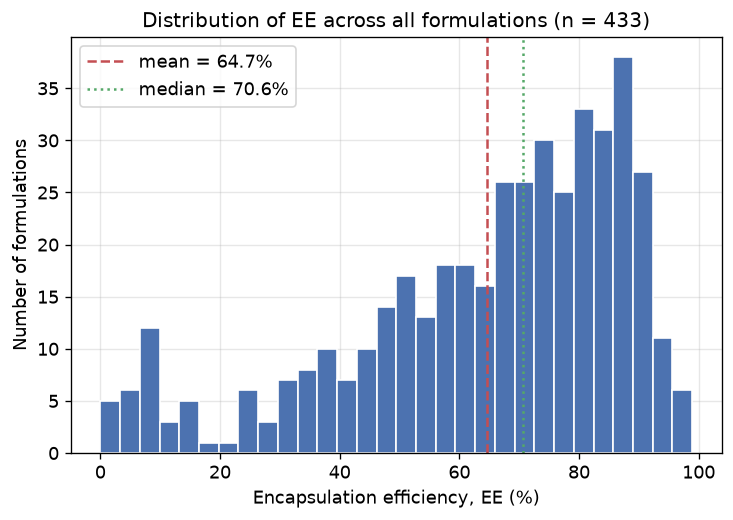

C:\Users\Ali sheroz\AppData\Local\Temp\ipykernel_4104\2103483356.py:12: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(master["EE"], vert=True, widths=0.5, patch_artist=True,


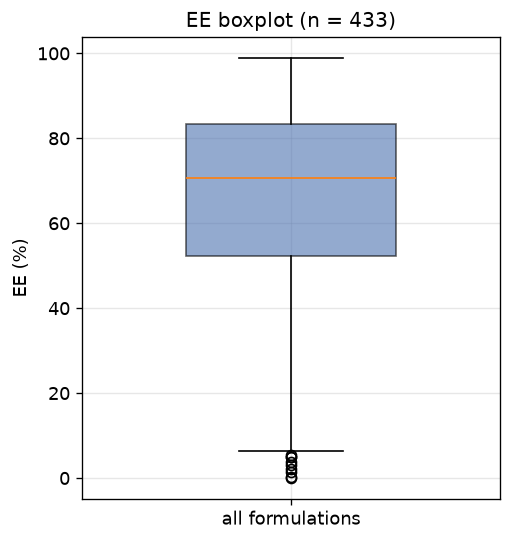

In [20]:
# Fig 1 — EE histogram
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(master["EE"], bins=30, color="#4C72B0", edgecolor="white")
ax.axvline(master["EE"].mean(), color="#C44E52", ls="--", lw=1.5, label=f"mean = {master['EE'].mean():.1f}%")
ax.axvline(master["EE"].median(), color="#55A868", ls=":", lw=1.5, label=f"median = {master['EE'].median():.1f}%")
ax.set_xlabel("Encapsulation efficiency, EE (%)"); ax.set_ylabel("Number of formulations")
ax.set_title(f"Distribution of EE across all formulations (n = {len(master)})"); ax.legend()
fig.savefig(FIG / "01_EE_histogram.png"); plt.show()

# Fig 2 — EE boxplot
fig, ax = plt.subplots(figsize=(4.5, 5))
ax.boxplot(master["EE"], vert=True, widths=0.5, patch_artist=True,
           boxprops=dict(facecolor="#4C72B0", alpha=0.6))
ax.set_ylabel("EE (%)"); ax.set_xticks([1]); ax.set_xticklabels(["all formulations"])
ax.set_title(f"EE boxplot (n = {len(master)})")
fig.savefig(FIG / "02_EE_boxplot.png"); plt.show()

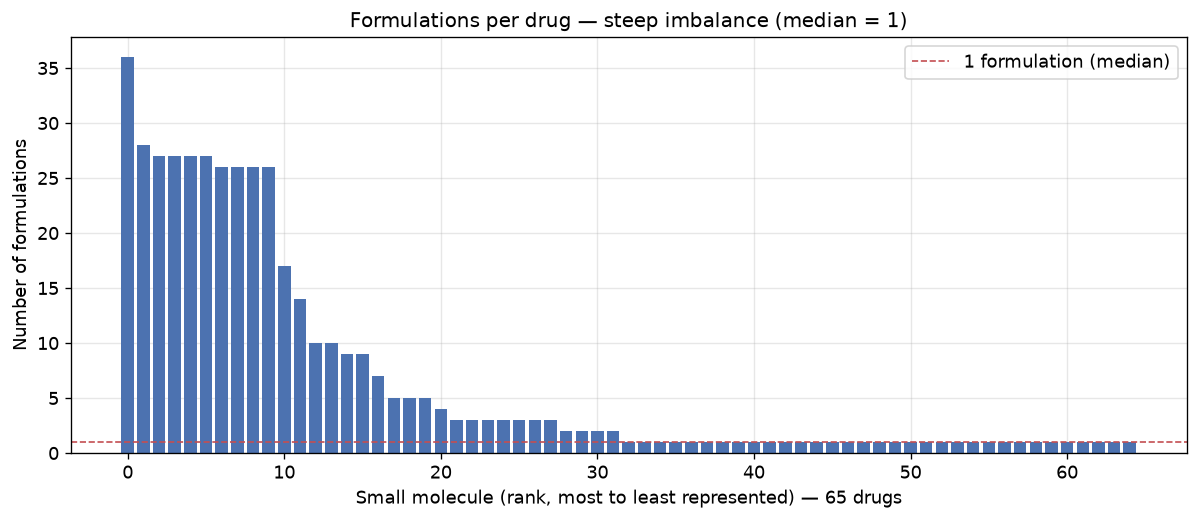

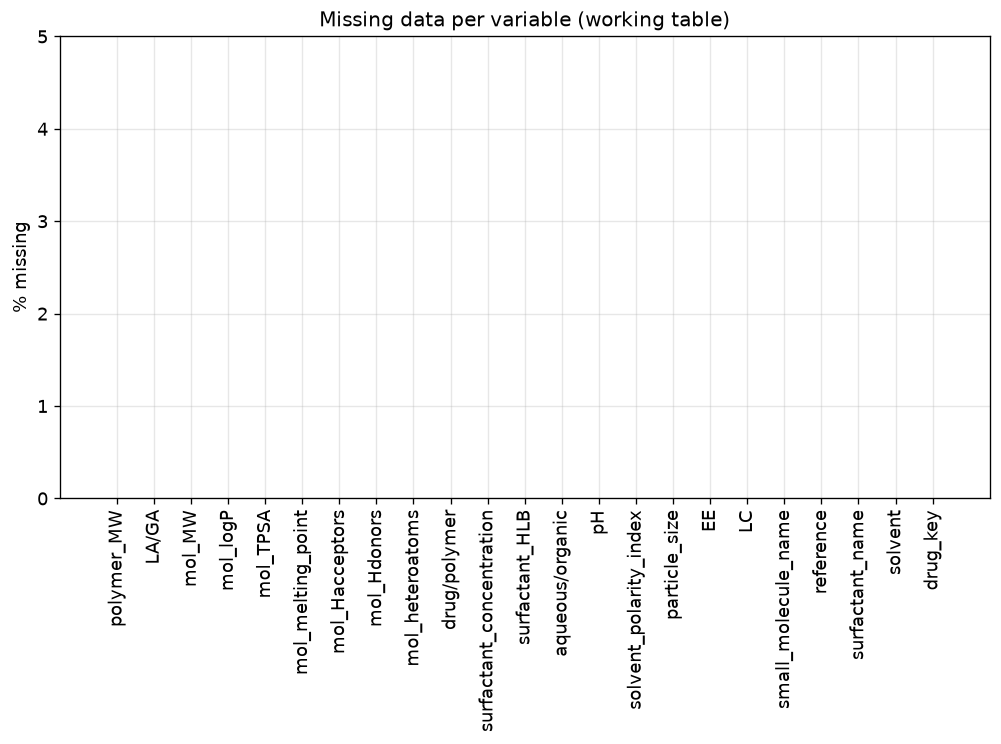

All core analysis variables are 100% complete.


In [21]:
# Fig 3 — formulations per drug (all drugs, sorted)
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.bar(range(len(per_drug)), per_drug["n_formulations"], color="#4C72B0")
ax.set_xlabel(f"Small molecule (rank, most to least represented) — {len(per_drug)} drugs")
ax.set_ylabel("Number of formulations")
ax.set_title("Formulations per drug — steep imbalance (median = 1)")
ax.axhline(1, color="#C44E52", ls="--", lw=1, label="1 formulation (median)")
ax.legend()
fig.savefig(FIG / "03_formulations_per_drug_bar.png"); plt.show()

# Fig 4 — missingness bar (all working-table variables)
mvals = (master.isna().mean() * 100).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(len(mvals)), mvals.values, color="#8172B3")
ax.set_xticks(range(len(mvals))); ax.set_xticklabels(mvals.index, rotation=90)
ax.set_ylabel("% missing"); ax.set_title("Missing data per variable (working table)")
ax.set_ylim(0, max(5, mvals.max() * 1.1 + 1))
fig.savefig(FIG / "04_missingness_bar.png"); plt.show()
print("All core analysis variables are 100% complete." if mvals.max() == 0 else "See figure for missingness.")

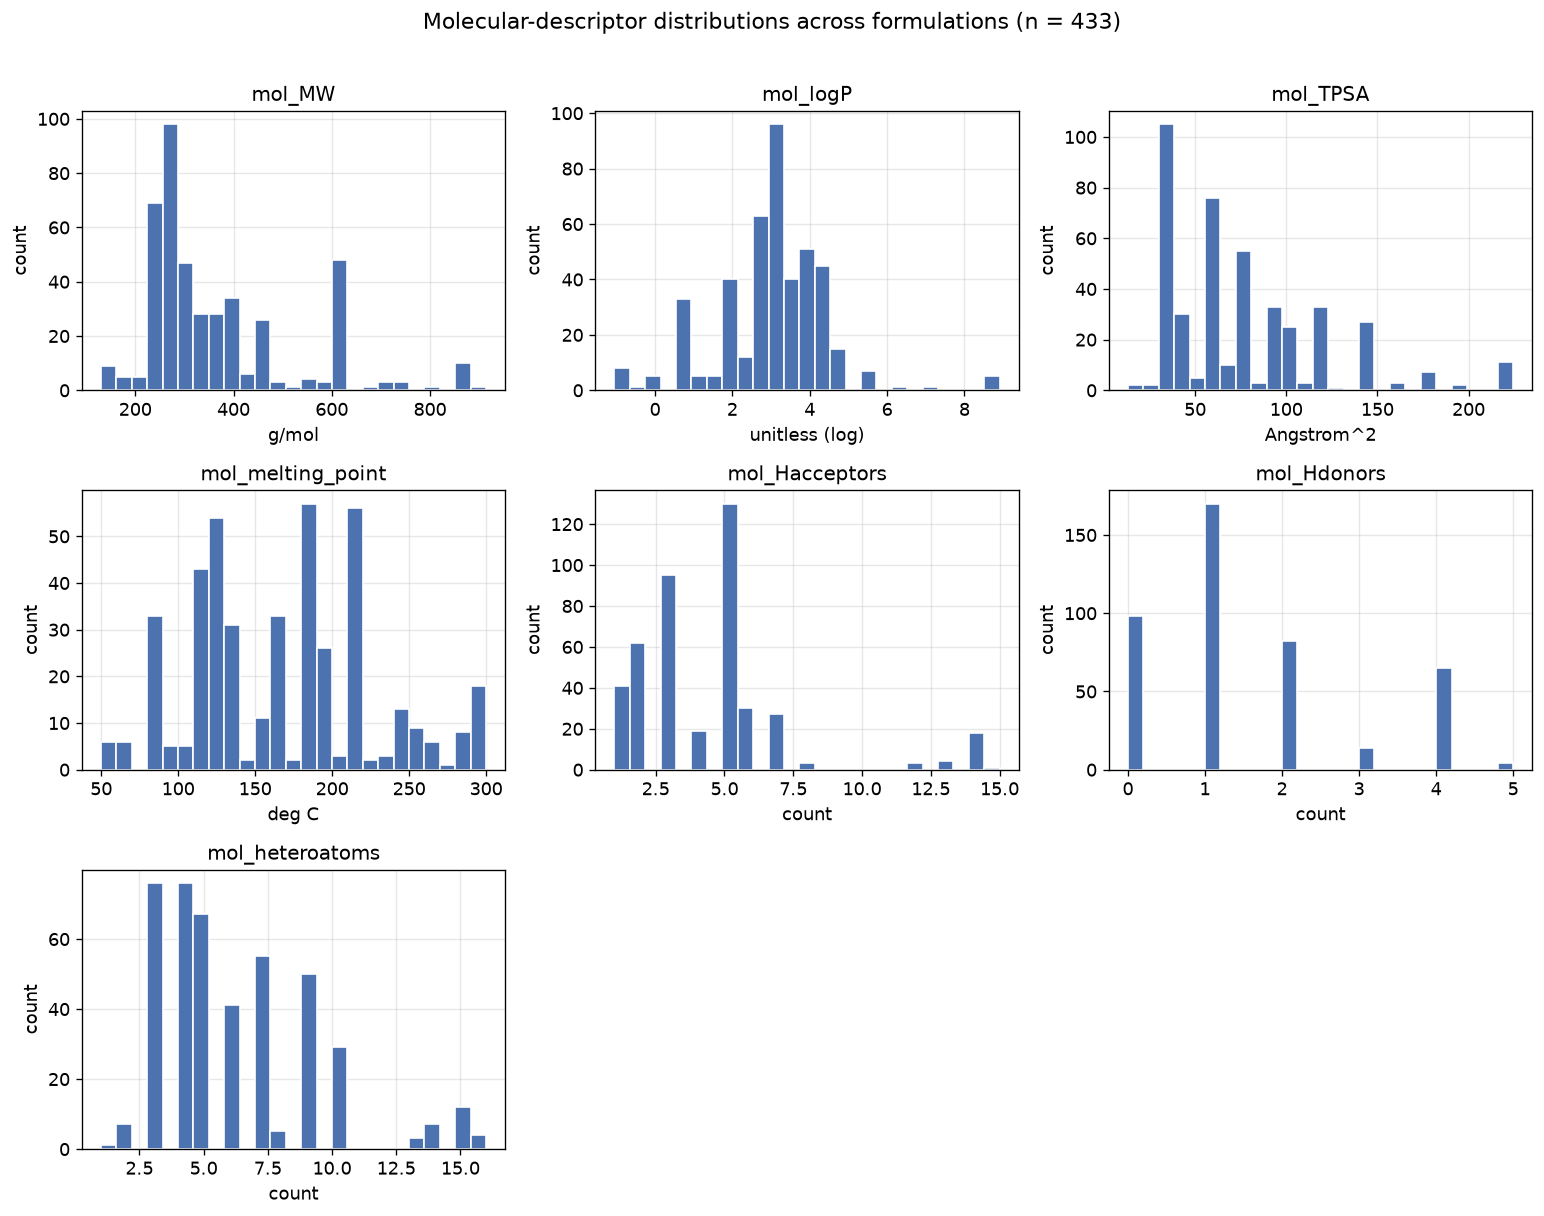

In [22]:
# Fig 5 — molecular descriptor distributions (per-formulation, i.e. what the model sees)
mol_desc = ["mol_MW","mol_logP","mol_TPSA","mol_melting_point","mol_Hacceptors","mol_Hdonors","mol_heteroatoms"]
fig, axes = plt.subplots(3, 3, figsize=(13, 10)); axes = axes.ravel()
for i, c in enumerate(mol_desc):
    axes[i].hist(master[c], bins=25, color="#4C72B0", edgecolor="white")
    axes[i].set_title(c); axes[i].set_xlabel(variable_dictionary.set_index("variable_name").loc[c,"unit_if_known"])
    axes[i].set_ylabel("count")
for j in range(len(mol_desc), len(axes)): axes[j].axis("off")
fig.suptitle("Molecular-descriptor distributions across formulations (n = %d)" % len(master), y=1.01)
fig.tight_layout(); fig.savefig(FIG / "05_molecular_descriptor_distributions.png"); plt.show()

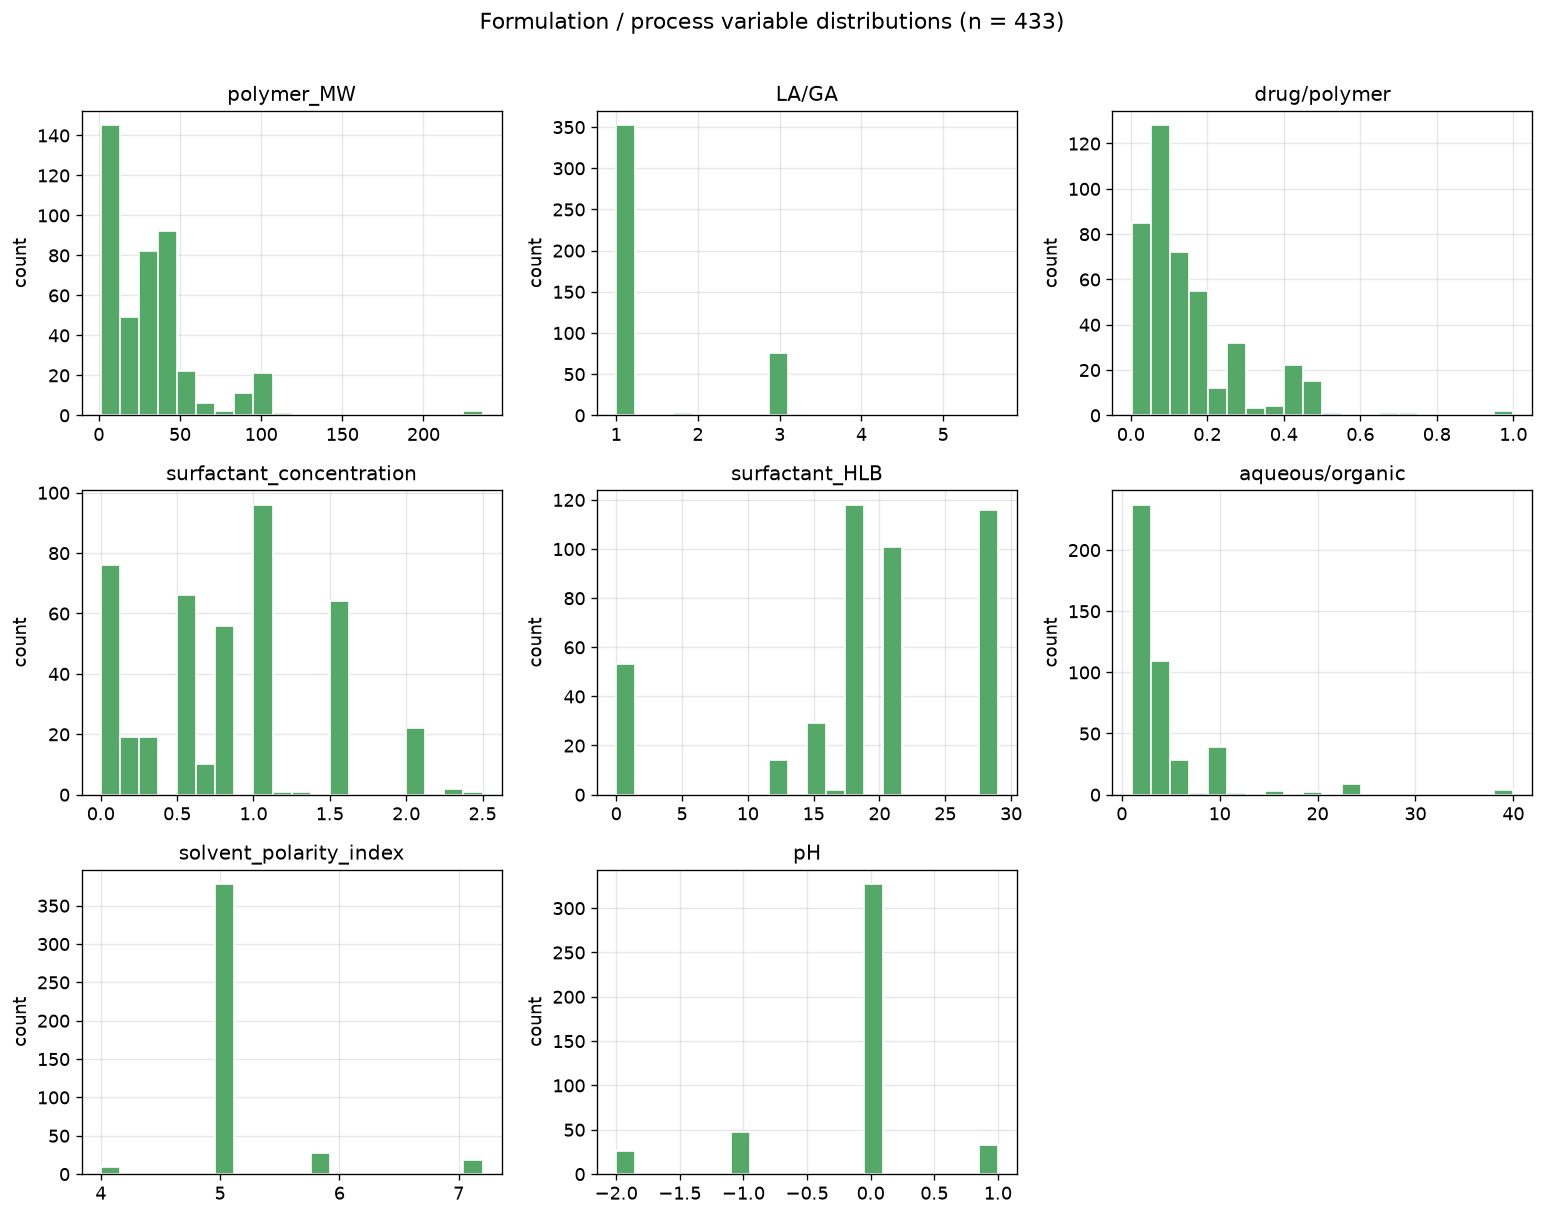

In [23]:
# Fig 6 — formulation-variable distributions
form_plot = ["polymer_MW","LA/GA","drug/polymer","surfactant_concentration",
             "surfactant_HLB","aqueous/organic","solvent_polarity_index","pH"]
fig, axes = plt.subplots(3, 3, figsize=(13, 10)); axes = axes.ravel()
for i, c in enumerate(form_plot):
    axes[i].hist(master[c], bins=20, color="#55A868", edgecolor="white")
    axes[i].set_title(c); axes[i].set_ylabel("count")
for j in range(len(form_plot), len(axes)): axes[j].axis("off")
fig.suptitle("Formulation / process variable distributions (n = %d)" % len(master), y=1.01)
fig.tight_layout(); fig.savefig(FIG / "06_formulation_variable_distributions.png"); plt.show()

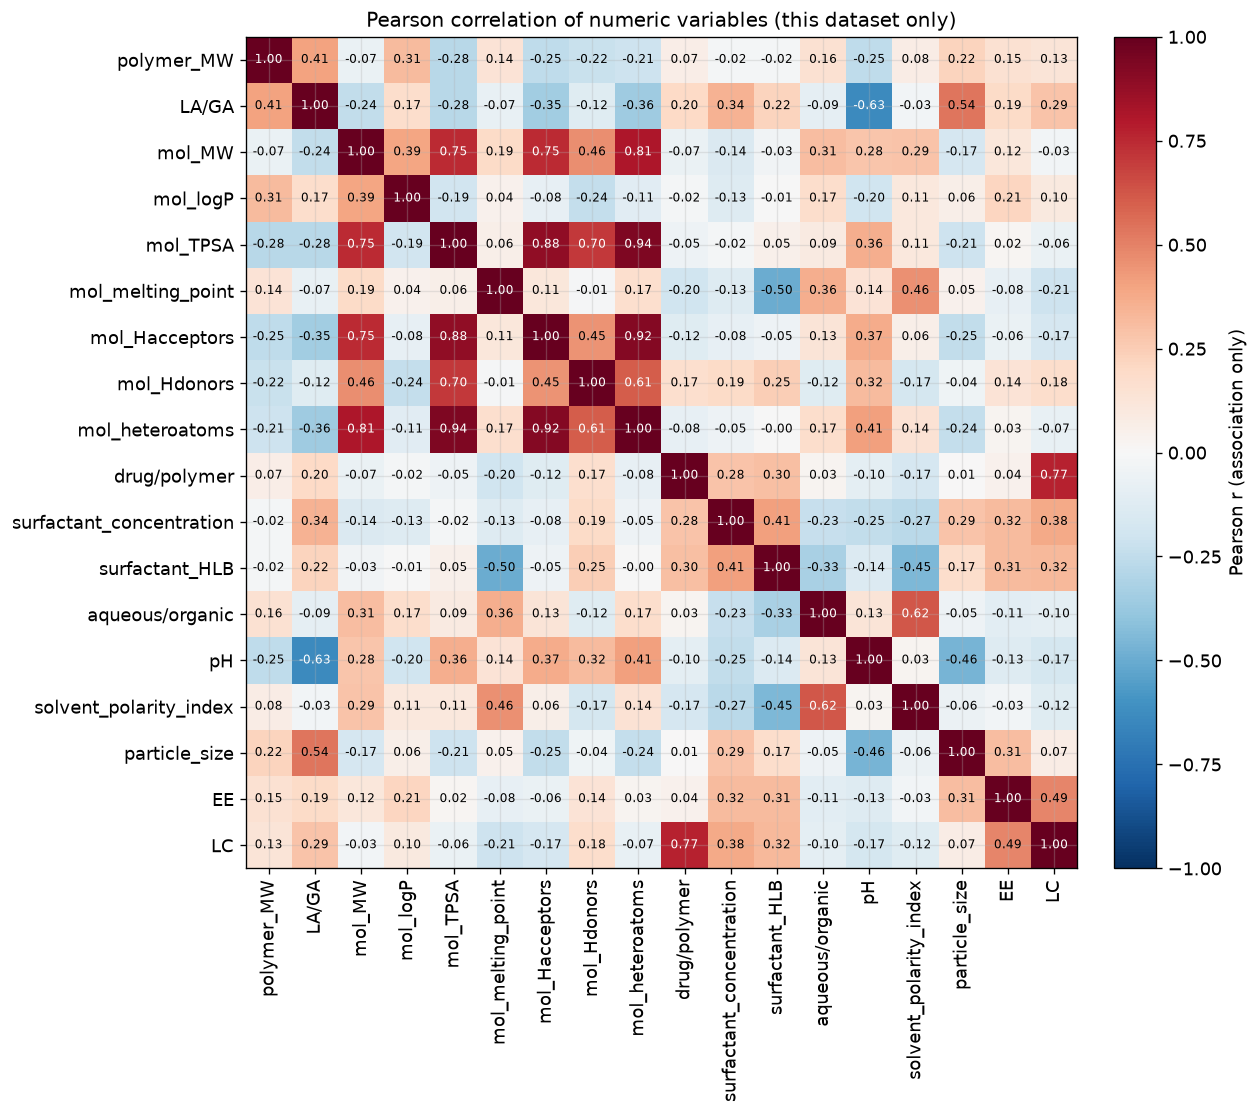

Pearson r(EE, LC) = 0.491  |  r(EE, particle_size) = 0.306
Top |correlations| of features with EE (association, NOT causation):


,index,abs_pearson_r_with_EE
0,surfactant_concentration,0.319
1,surfactant_HLB,0.313
2,mol_logP,0.215
3,LA/GA,0.192
4,polymer_MW,0.152
5,mol_Hdonors,0.136
6,pH,0.130
7,mol_MW,0.116


In [24]:
# Fig 7 — correlation matrix (all 18 numeric columns; Pearson). ASSOCIATION only, not causal.
corr = master[num_cols].corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(10, 9))
im = ax.imshow(corr.values, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(len(num_cols))); ax.set_xticklabels(num_cols, rotation=90)
ax.set_yticks(range(len(num_cols))); ax.set_yticklabels(num_cols)
for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        ax.text(j, i, f"{corr.values[i,j]:.2f}", ha="center", va="center",
                color="white" if abs(corr.values[i,j]) > 0.55 else "black", fontsize=7)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Pearson r (association only)")
ax.set_title("Pearson correlation of numeric variables (this dataset only)")
fig.savefig(FIG / "07_correlation_matrix.png"); plt.show()
print(f"Pearson r(EE, LC) = {corr.loc['EE','LC']:.3f}  |  r(EE, particle_size) = {corr.loc['EE','particle_size']:.3f}")
print("Top |correlations| of features with EE (association, NOT causation):")
ee_corr = corr["EE"].drop(["EE","LC","particle_size"]).abs().sort_values(ascending=False)
display(ee_corr.round(3).rename("abs_pearson_r_with_EE").reset_index().head(8))

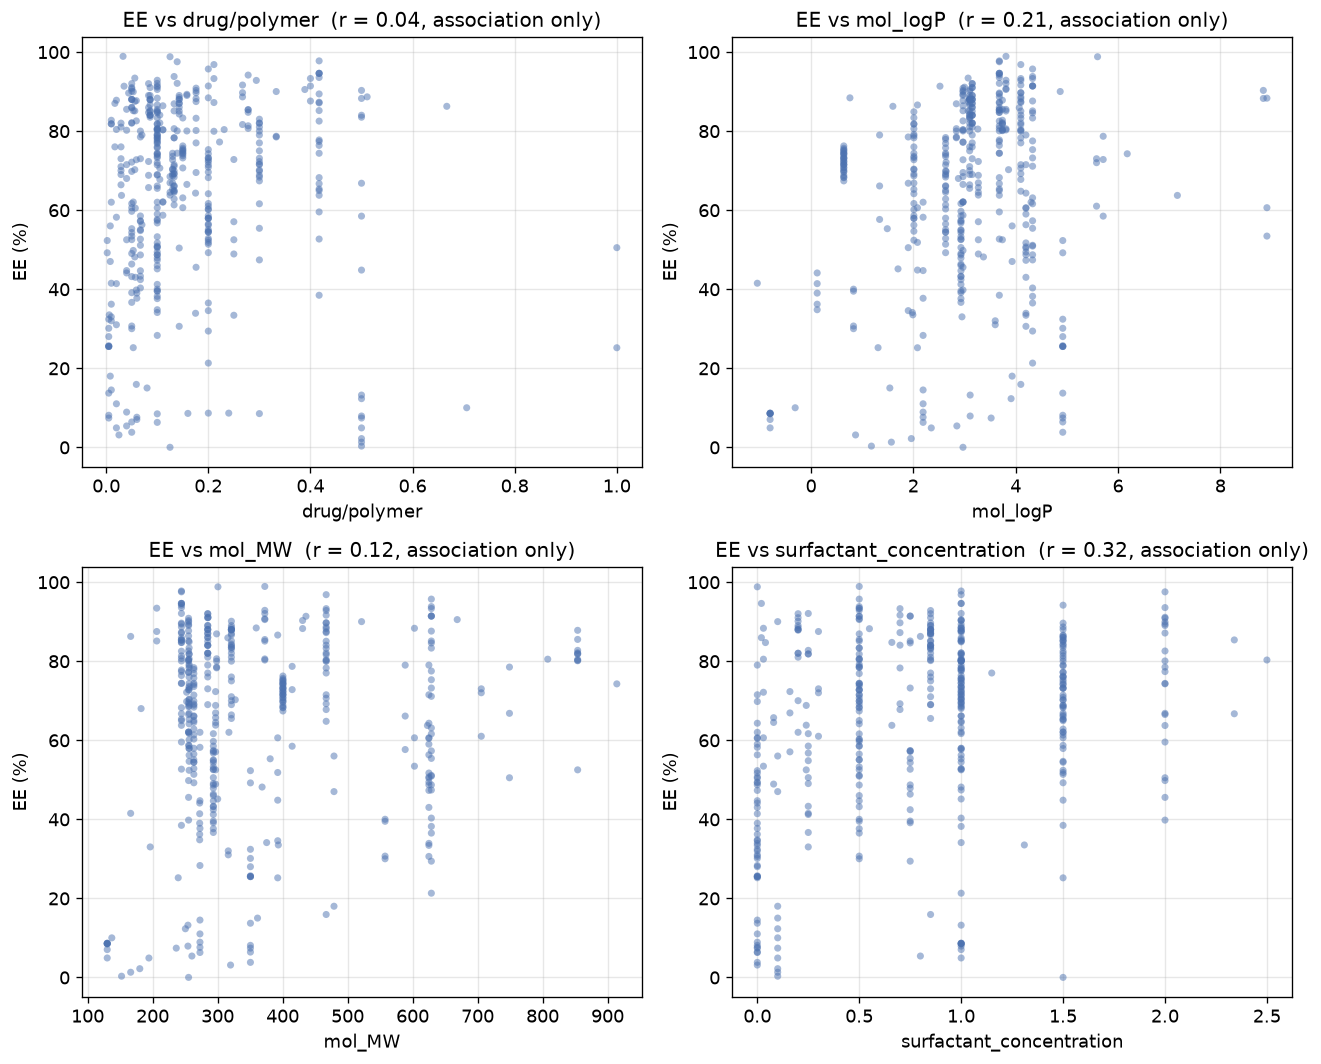

In [25]:
# Fig 8 — EE vs important continuous formulation/molecular variables
pairs = ["drug/polymer","mol_logP","mol_MW","surfactant_concentration"]
fig, axes = plt.subplots(2, 2, figsize=(11, 9)); axes = axes.ravel()
for i, c in enumerate(pairs):
    axes[i].scatter(master[c], master["EE"], s=18, alpha=0.5, color="#4C72B0", edgecolor="none")
    r = master[[c,"EE"]].corr().iloc[0,1]
    axes[i].set_xlabel(c); axes[i].set_ylabel("EE (%)")
    axes[i].set_title(f"EE vs {c}  (r = {r:.2f}, association only)")
fig.tight_layout(); fig.savefig(FIG / "08_EE_vs_formulation_variables.png"); plt.show()

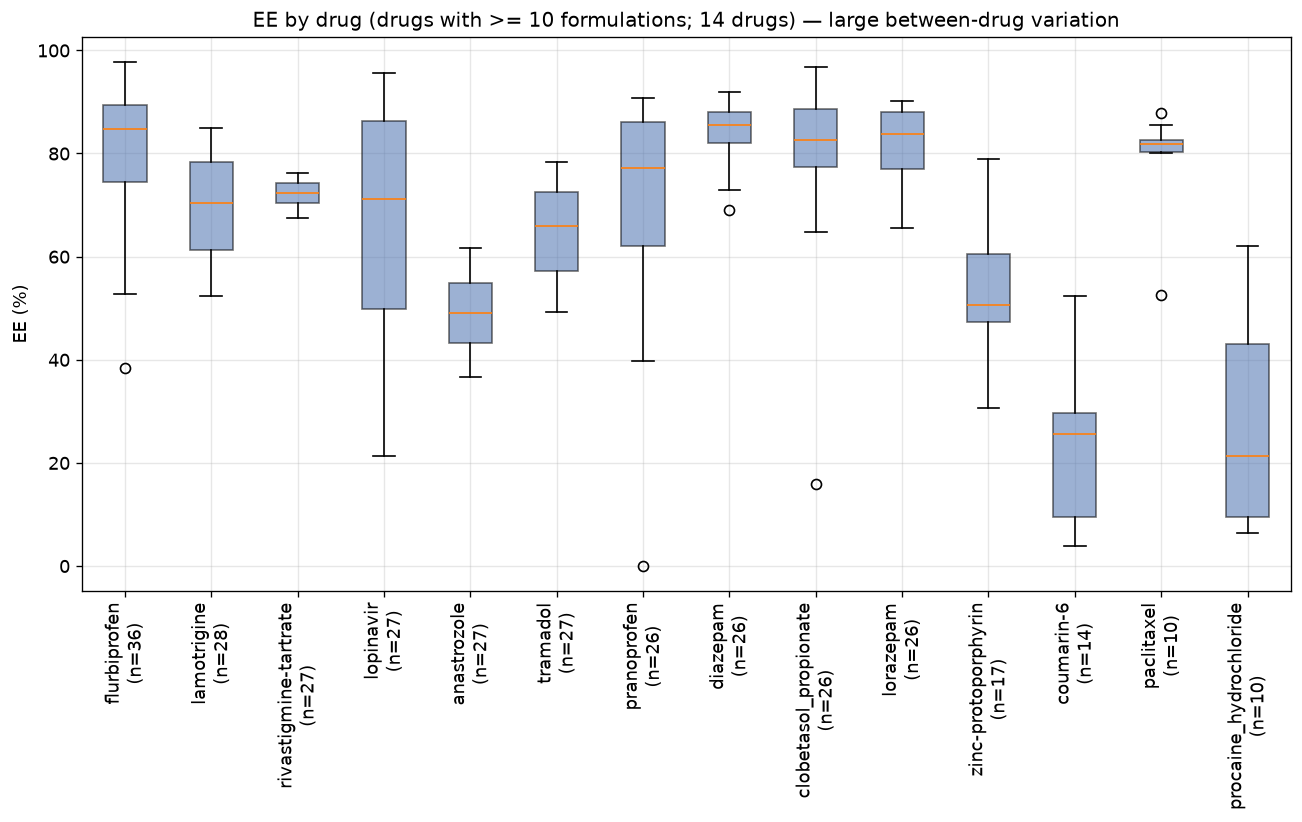

14 drugs have >= 10 formulations; they account for 327/433 = 76% of all formulations.


In [26]:
# Fig 9 — EE distribution across sufficiently represented drugs (>= 10 formulations)
THRESH = 10
well = per_drug[per_drug["n_formulations"] >= THRESH]["drug"].tolist()
groups = [master.loc[master["drug_key"] == d, "EE"].values for d in well]
labels = [f"{d}\n(n={len(v)})" for d, v in zip(well, groups)]
fig, ax = plt.subplots(figsize=(13, 6))
ax.boxplot(groups, tick_labels=labels, patch_artist=True,
           boxprops=dict(facecolor="#4C72B0", alpha=0.55))
ax.set_ylabel("EE (%)")
ax.set_title(f"EE by drug (drugs with >= {THRESH} formulations; {len(well)} drugs) — large between-drug variation")
plt.setp(ax.get_xticklabels(), rotation=90)
fig.savefig(FIG / "09_EE_by_drug_boxplot.png"); plt.show()
print(f"{len(well)} drugs have >= {THRESH} formulations; they account for "
      f"{sum(len(v) for v in groups)}/{len(master)} = "
      f"{sum(len(v) for v in groups)/len(master)*100:.0f}% of all formulations.")

## 19. Unseen-drug feasibility analysis
Using `drug_key` as the conceptual group, we quantify whether the structure supports evaluation on drugs excluded from training, and discuss candidate validation schemes. **No models are run.**

In [27]:
n_ge2 = int((per_drug["n_formulations"] >= 2).sum())
n_ge3 = int((per_drug["n_formulations"] >= 3).sum())
n_ge5 = int((per_drug["n_formulations"] >= 5).sum())
n_ge10 = int((per_drug["n_formulations"] >= 10).sum())
print(f"Unique drugs: {len(per_drug)}")
print(f"Drugs with >=2 formulations: {n_ge2}  | >=3: {n_ge3}  | >=5: {n_ge5}  | >=10: {n_ge10}")
print(f"Singletons (1 formulation): {int((per_drug['n_formulations']==1).sum())} "
      f"({(per_drug['n_formulations']==1).mean()*100:.0f}% of drugs, but only "
      f"{int((per_drug['n_formulations']==1).sum())}/{len(master)} = "
      f"{(per_drug['n_formulations']==1).sum()/len(master)*100:.0f}% of formulations)")
print(f"Top-10 drugs contribute {per_drug.head(10)['n_formulations'].sum()/len(master)*100:.0f}% of all formulations.")
print(f"Drugs confined to a single publication: {int((master.groupby('drug_key')['reference'].nunique()==1).sum())}/{len(per_drug)}")
print(textwrap.dedent("""
    Validation-scheme suitability (feasibility only — not executed here):
      A. GroupKFold by drug        -> RECOMMENDED. Each drug is wholly in train or test; every
                                      formulation is tested exactly once as an 'unseen drug'. Robust
                                      to the 33 singletons. Use ~5 folds; stratify folds by drug size.
      B. GroupShuffleSplit by drug -> Useful companion for repeated random held-out drug sets to get
                                      variance estimates; report mean +/- SD over many repeats.
      C. Leave-One-Drug-Out (LODO) -> Interpretable per-drug error, BUT with 33 singleton drugs each
                                      such fold tests a single formulation -> extremely noisy per-drug
                                      metrics; overall LODO error is dominated by many tiny test sets.
                                      Report as a secondary, aggregate view at most; do NOT rely on
                                      individual singleton-drug scores.
      D. Repeated grouped CV       -> Sensible: repeat GroupKFold with several seeds and average, to
                                      damp the effect of which big drugs land in which fold.
    Recommendation: primary = repeated GroupKFold-by-drug; secondary = LODO reported only in aggregate.
    Also consider a study-level (GroupKFold by 'reference') robustness check, since many drugs are
    confined to one publication (drug and study identity are partly confounded).
"""))

Unique drugs: 65
Drugs with >=2 formulations: 32  | >=3: 28  | >=5: 20  | >=10: 14
Singletons (1 formulation): 33 (51% of drugs, but only 33/433 = 8% of formulations)
Top-10 drugs contribute 64% of all formulations.
Drugs confined to a single publication: 62/65

Validation-scheme suitability (feasibility only — not executed here):
  A. GroupKFold by drug        -> RECOMMENDED. Each drug is wholly in train or test; every
                                  formulation is tested exactly once as an 'unseen drug'. Robust
                                  to the 33 singletons. Use ~5 folds; stratify folds by drug size.
  B. GroupShuffleSplit by drug -> Useful companion for repeated random held-out drug sets to get
                                  variance estimates; report mean +/- SD over many repeats.
  C. Leave-One-Drug-Out (LODO) -> Interpretable per-drug error, BUT with 33 singleton drugs each
                                  such fold tests a single formulation -> extremely noisy per-

## 20. Feasibility of Unseen-Drug Encapsulation-Efficiency Prediction
The final report (answers A–L + overall classification) is assembled from the computed numbers and written to `results/audit/feasibility_report.md`.

In [28]:
M = {
    "n_form": n_form, "n_drugs": n_drugs, "n_pubs": n_pubs,
    "ee_present": ee_present, "ee_missing": ee_missing,
    "ee_min": ee.min(), "ee_max": ee.max(), "ee_mean": round(ee.mean(),1), "ee_median": ee.median(),
    "singletons": int((per_drug["n_formulations"]==1).sum()),
    "singleton_pct_drugs": round((per_drug["n_formulations"]==1).mean()*100),
    "n_ge5": n_ge5, "n_ge10": n_ge10, "n_ge3": n_ge3, "n_ge2": n_ge2,
    "top10_share": round(per_drug.head(10)["n_formulations"].sum()/n_form*100),
    "median_fpd": per_drug["n_formulations"].median(), "max_fpd": int(per_drug["n_formulations"].max()),
    "single_pub_drugs": int((master.groupby('drug_key')['reference'].nunique()==1).sum()),
    "r_ee_lc": round(corr.loc['EE','LC'],2), "r_ee_ps": round(corr.loc['EE','particle_size'],2),
    "exact_dups": int(fin.duplicated().sum()),
    "logp_min": round(master["mol_logP"].min(),2), "logp_max": round(master["mol_logP"].max(),2),
    "logp_p25": round(master.drop_duplicates("drug_key")["mol_logP"].quantile(.25),2),
    "logp_p75": round(master.drop_duplicates("drug_key")["mol_logP"].quantile(.75),2),
    "pct_logp_0_5": round(master.drop_duplicates("drug_key")["mol_logP"].between(0,5).mean()*100),
}
report = f"""# Feasibility of Unseen-Drug Encapsulation-Efficiency Prediction
**Phase 1 data feasibility audit — PLGA-EE-Generalization**

Dataset: Goren et al., *Scientific Data* (2025) 12:1182 · Mendeley DOI `10.17632/sbjf5csrdm.1` · License CC BY 4.0.
All five files verified against official Mendeley SHA256 hashes (see `source_manifest.csv`). No values were modified, imputed, or synthesised.

## Plain-language summary (for a non-specialist reviewer)
We want to predict how much drug gets trapped inside a PLGA nanoparticle (**encapsulation efficiency, EE%**), and — crucially — to test whether a model can do this for **drugs it has never seen before**. The dataset has **{M['n_form']} formulations** covering **{M['n_drugs']} different small-molecule drugs** from **{M['n_pubs']} published studies**. The good news: EE is recorded for **every** formulation, the molecular and formulation inputs are complete, and each drug has the chemical descriptors a model needs. The catch: the drugs are **very unevenly represented** — half of them ({M['singletons']} of {M['n_drugs']}) appear in only a **single** formulation, while a handful of drugs dominate. That imbalance shapes *how* we must test the model (grouped cross-validation, not naive random splits), but it does **not** block the project. Verdict: **feasible with modifications.**

## A. Is EE sufficiently available to serve as the primary regression target?
**Yes.** EE is present for {M['ee_present']}/{M['n_form']} formulations ({round(M['ee_present']/M['n_form']*100)}%); {M['ee_missing']} missing. Range {M['ee_min']:.1f}–{M['ee_max']:.1f}% (mean {M['ee_mean']}, median {M['ee_median']}), all within the plausible 0–100% bound. Caveat: per the Methods, some EE values were back-calculated from LC when EE was unreported — a reason to (a) exclude LC as a feature and (b) later flag which EE values were derived.

## B. How many unique drugs have usable EE observations?
All **{M['n_drugs']}** unique drugs have at least one formulation with EE. But "usable for testing generalisation" depends on count: **{M['n_ge2']}** drugs have ≥2 formulations, **{M['n_ge3']}** have ≥3, **{M['n_ge5']}** have ≥5, and **{M['n_ge10']}** have ≥10.

## C. How uneven is the number of formulations per drug?
**Severely uneven.** Median = {M['median_fpd']:.0f} formulation per drug, max = {M['max_fpd']}. Singletons: **{M['singletons']} drugs ({M['singleton_pct_drugs']}% of drugs)**. The 10 most common drugs account for **{M['top10_share']}%** of all formulations.

## D. Is drug-grouped validation possible?
**Yes.** Drug identity is recoverable for every row (via the row-aligned `NP_dataset_formulations.csv`), giving a clean group label. GroupKFold / GroupShuffleSplit by drug are directly applicable.

## E. Would literal Leave-One-Drug-Out be scientifically sensible?
**Only as a secondary, aggregate view.** With {M['singletons']} singleton drugs, most LODO folds would test a single formulation, so per-drug metrics would be very noisy and easily misread. Report LODO only in aggregate, never as reliable individual-drug scores.

## F. Would GroupKFold be more defensible?
**Yes — recommended primary scheme.** Repeated GroupKFold-by-drug (≈5 folds, several seeds, averaged) tests every formulation once as an unseen drug while remaining stable despite the singletons.

## G. Which variables are suitable candidate predictors?
Molecular descriptors (mol_MW, mol_logP, mol_TPSA, mol_melting_point, mol_Hacceptors, mol_Hdonors, mol_heteroatoms), polymer descriptors (polymer_MW, LA/GA), process variables (drug/polymer, surfactant_concentration, aqueous/organic, pH*), and excipient/solvent descriptors (surfactant_HLB, solvent_polarity_index). *pH is an ordinal code, not raw pH.

## H. Which variables must be excluded because of leakage?
**LC (definite leakage** — inter-convertible with EE via formulation quantities; r(EE,LC)={M['r_ee_lc']} here, but the leakage is structural, not just correlational). **particle_size** (measured outcome, not a pre-formulation design variable; r(EE,particle_size)={M['r_ee_ps']}). **Drug identity / reference** may be used only for grouping, never as features.

## I. Are molecular descriptors adequate for an unseen-drug study?
**Adequate, but the chemical space is concentrated.** Every drug has SMILES + RDKit descriptors + melting point (0% missing), so any new small molecule can be featurised. Consistent with the authors' note on constrained chemical diversity, the drugs cluster in a narrow lipophilicity band: per-drug logP IQR ≈ {M['logp_p25']}–{M['logp_p75']} and {M['pct_logp_0_5']}% of the 65 drugs fall within logP 0–5, with only a few outliers stretching the full range to {M['logp_min']}–{M['logp_max']}. Generalisation claims must therefore be scoped to this well-populated region; drugs far outside it (very hydrophilic or very lipophilic) are extrapolation and should be flagged as such.

## J. Are there major missing-data problems?
**No.** The 18 analytical variables are 100% complete across all {M['n_form']} formulations; identity columns are complete too.

## K. Are there publication/study-level clustering concerns?
**Yes.** {M['n_pubs']} studies; **{M['single_pub_drugs']}/{M['n_drugs']}** drugs appear in only one publication, so drug identity and study identity are partly confounded (a model may learn study "fingerprints"). Add a study-level (GroupKFold-by-reference) robustness check alongside the drug-level evaluation. Also note {M['exact_dups']} exact duplicate rows flagged for review.

## L. Does the dataset support my current research title?
**Yes, with modifications.** The data supports "predicting EE for unseen small-molecule drugs in PLGA nanoparticles" provided the evaluation uses drug-grouped CV (not random splits), LC and particle_size are excluded as predictors, pH is handled as an ordinal code, and generalisation claims are scoped to the dataset's limited chemical space and the singleton-heavy drug distribution.

---
# OVERALL CLASSIFICATION: **FEASIBLE WITH MODIFICATIONS**

**Why:** EE is fully available, clean, and drug identity is cleanly recoverable, so the core experiment is possible. The required modifications are: (1) drug-grouped, repeated cross-validation (GroupKFold-by-drug primary; LODO aggregate-only) because {M['singleton_pct_drugs']}% of drugs are singletons; (2) exclude LC (definite leakage) and particle_size (measured outcome) from predictors; (3) treat pH as an ordinal encoded variable and clarify the undocumented "-2" code; (4) add a study-level robustness check given {M['single_pub_drugs']}/{M['n_drugs']} drugs are confined to one publication; (5) scope generalisation claims to the constrained chemical space; (6) review the {M['exact_dups']} flagged duplicate rows. None of these block the project — they define an honest, leakage-free evaluation protocol.
"""
(AUD / "feasibility_report.md").write_text(report, encoding="utf-8")
print(report)

# Feasibility of Unseen-Drug Encapsulation-Efficiency Prediction
**Phase 1 data feasibility audit — PLGA-EE-Generalization**

Dataset: Goren et al., *Scientific Data* (2025) 12:1182 · Mendeley DOI `10.17632/sbjf5csrdm.1` · License CC BY 4.0.
All five files verified against official Mendeley SHA256 hashes (see `source_manifest.csv`). No values were modified, imputed, or synthesised.

## Plain-language summary (for a non-specialist reviewer)
We want to predict how much drug gets trapped inside a PLGA nanoparticle (**encapsulation efficiency, EE%**), and — crucially — to test whether a model can do this for **drugs it has never seen before**. The dataset has **433 formulations** covering **65 different small-molecule drugs** from **59 published studies**. The good news: EE is recorded for **every** formulation, the molecular and formulation inputs are complete, and each drug has the chemical descriptors a model needs. The catch: the drugs are **very unevenly represented** — half of them (

In [29]:
# --- Output inventory: confirm every required artefact was written ---
expected = [
    TAB/"dataset_file_map.csv", TAB/"variable_dictionary.csv", TAB/"missingness_summary.csv",
    TAB/"formulations_per_drug.csv", TAB/"EE_summary.csv", TAB/"leakage_audit.csv",
    TAB/"duplicate_audit.csv", TAB/"outlier_flags.csv", TAB/"formulations_per_drug_buckets.csv",
    AUD/"source_manifest.csv", AUD/"feasibility_report.md",
    PROC/"master_audit_view.csv",
] + [FIG/f for f in [
    "01_EE_histogram.png","02_EE_boxplot.png","03_formulations_per_drug_bar.png",
    "04_missingness_bar.png","05_molecular_descriptor_distributions.png",
    "06_formulation_variable_distributions.png","07_correlation_matrix.png",
    "08_EE_vs_formulation_variables.png","09_EE_by_drug_boxplot.png"]]
print("OUTPUT INVENTORY")
for p in expected:
    print(f"  [{'OK' if p.exists() else 'MISSING'}] {p.relative_to(ROOT)}")
print("\nPhase 1 dataset feasibility audit complete.")

OUTPUT INVENTORY
  [OK] results\tables\dataset_file_map.csv
  [OK] results\tables\variable_dictionary.csv
  [OK] results\tables\missingness_summary.csv
  [OK] results\tables\formulations_per_drug.csv
  [OK] results\tables\EE_summary.csv
  [OK] results\tables\leakage_audit.csv
  [OK] results\tables\duplicate_audit.csv
  [OK] results\tables\outlier_flags.csv
  [OK] results\tables\formulations_per_drug_buckets.csv
  [OK] results\audit\source_manifest.csv
  [OK] results\audit\feasibility_report.md
  [OK] data\processed\master_audit_view.csv
  [OK] results\figures\01_EE_histogram.png
  [OK] results\figures\02_EE_boxplot.png
  [OK] results\figures\03_formulations_per_drug_bar.png
  [OK] results\figures\04_missingness_bar.png
  [OK] results\figures\05_molecular_descriptor_distributions.png
  [OK] results\figures\06_formulation_variable_distributions.png
  [OK] results\figures\07_correlation_matrix.png
  [OK] results\figures\08_EE_vs_formulation_variables.png
  [OK] results\figures\09_EE_by_dr